In [71]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [72]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [73]:
# 재수집 직후 즉시 날짜 고정
df["SQLDATE"] = pd.to_datetime(
    df["SQLDATE"].astype(str).str[:8],
    format="%Y%m%d", errors="coerce"
)
print(df["SQLDATE"].head(3))
print(f"NaT: {df['SQLDATE'].isna().sum()}")

0   2026-05-08
1   2026-05-08
2   2026-05-08
Name: SQLDATE, dtype: datetime64[ns]
NaT: 0


In [ ]:

# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE,
    IsRootEvent,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    EventBaseCode,
    EventRootCode,
    GoldsteinScale,
    QuadClass,
    NumMentions,
    NumArticles,
    NumSources,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})

"""
df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())


In [74]:
# BigQuery에서 받을 때 SQLDATE가 정수형(20260510)으로 오는데, pandas_gbq가 이걸 날짜로 자동 변환하려다 실패해서 NaT 나옴
# 쿼리에서 문자열로 받으면 해결
query = f"""
SELECT 
    CAST(SQLDATE AS STRING) AS SQLDATE,  -- 문자열로 변환
    IsRootEvent,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    EventBaseCode,
    EventRootCode,
    GoldsteinScale,
    QuadClass,
    NumMentions,
    NumArticles,
    NumSources,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'
)

# 수집 후 날짜 변환
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"], format="%Y%m%d")

print(f"총 {len(df):,}건 수집 완료")
print(f"날짜 범위: {df['SQLDATE'].min()} ~ {df['SQLDATE'].max()}")
print(f"NaT 비율: {df['SQLDATE'].isna().mean():.1%}")
display(df.head())

Downloading: 100%|██████████|
총 11,941건 수집 완료
날짜 범위: 2013-04-01 00:00:00 ~ 2026-05-14 00:00:00
NaT 비율: 0.0%


,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL
0,2016-08-20,1,TWN,CHN,192,192,19,-9.5,4,5,5,1,-3.697749,4,27.9383,116.293,"Lin Chuan, Jiangxi, China",CH,http://www.chinapost.com.tw/taiwan/national/na...
1,2016-08-20,1,TWN,CHN,192,192,19,-9.5,4,5,5,1,-3.697749,4,27.9383,116.293,"Lin Chuan, Jiangxi, China",CH,http://www.chinapost.com.tw/taiwan/national/na...
2,2016-08-20,1,TWN,CHN,194,194,19,-10.0,4,8,8,1,-1.573850,4,39.9289,116.388,"Beijing, Beijing, China",CH,http://www.newsnow.in/news/taiwan-president-sa...
3,2016-08-20,1,TWN,CHN,194,194,19,-10.0,4,2,2,1,-1.573850,4,25.0478,121.532,"Taipei, T'ai-pei, Taiwan",TW,http://www.newsnow.in/news/taiwan-president-sa...
4,2016-09-25,1,TWN,CHN,202,202,20,-10.0,4,4,4,1,-2.666667,4,39.9044,116.391,"Tiananmen Square, Beijing, China",CH,http://nationalinterest.org/feature/how-spark-...


In [ ]:
import pandas as pd

# 기본 파악
print("shape:", df.shape)
print("\n결측값 비율(%)")
print((df.isnull().mean() * 100).round(2))

# 날짜 변환
df["SQLDATE"] = pd.to_datetime(
    df["SQLDATE"].astype(str).str.zfill(8),
    format="%Y%m%d", errors="coerce"
)
print(df["SQLDATE"].head())
print(f"NaT 비율: {df['SQLDATE'].isna().mean():.1%}")

# 연도별 분포
df['year'] = df['SQLDATE'].dt.year
print("\n연도별 이벤트 수")
print(df['year'].value_counts().sort_index())

In [ ]:
# BigQuery 원본 df에서 SQLDATE 실제 값 확인
# 변환 전 raw 값 보기
print(type(df["SQLDATE"].iloc[0]))
print(repr(df["SQLDATE"].iloc[0]))

# 혹시 다른 컬럼명으로 날짜가 있는지
print(df.columns.tolist())
print(df.head(2).to_string())

In [ ]:
print(df.head)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

In [ ]:
"""
군사 시설 반경 검증
1단계: GDELT 이벤트 → 최근접 군사 시설 거리 분포
2단계: 스파이크 날짜 역산 → 의미 있는 반경 추정
3단계: 반경별 민감도 분석 (10·20·30·50km)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 대만 군사 시설 좌표 (이미지 기반) ───────────────────────────
MILITARY_FACILITIES = [
    # 육군
    {"name": "육군사령부",          "lat": 24.864, "lon": 121.238, "type": "육군"},
    {"name": "제6군단사령부",        "lat": 24.87,  "lon": 121.24,  "type": "육군"},
    {"name": "제21포병지휘부",       "lat": 24.912, "lon": 121.245, "type": "육군"},
    {"name": "제8군단사령부",        "lat": 22.845, "lon": 120.485, "type": "육군"},
    {"name": "제10군단사령부",       "lat": 24.232, "lon": 120.812, "type": "육군"},
    {"name": "진먼방위지휘부",       "lat": 24.448, "lon": 118.388, "type": "육군"},
    {"name": "마주방위지휘부",       "lat": 26.155, "lon": 119.936, "type": "육군"},
    {"name": "펑후방위지휘부",       "lat": 23.571, "lon": 119.574, "type": "육군"},
    # 해군
    {"name": "해군사령부",          "lat": 25.085, "lon": 121.538, "type": "해군"},
    {"name": "제124함대(가오슝)",    "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "제131함대(지룽항)",    "lat": 25.138, "lon": 121.748, "type": "해군"},
    {"name": "제146함대(광후마공항)","lat": 23.555, "lon": 119.565, "type": "해군"},
    {"name": "제151함대(가오슝)",    "lat": 22.69,  "lon": 120.288, "type": "해군"},
    {"name": "제168함대(쑤아오항)",  "lat": 24.598, "lon": 121.872, "type": "해군"},
    {"name": "제192함대(가오슝)",    "lat": 22.691, "lon": 120.287, "type": "해군"},
    {"name": "진먼기지지휘부",       "lat": 24.415, "lon": 118.299, "type": "해군"},
    {"name": "마쭈기지지휘부",       "lat": 26.158, "lon": 119.925, "type": "해군"},
    # 공군
    {"name": "공군사령부",          "lat": 25.085, "lon": 121.538, "type": "공군"},
    {"name": "제1전술전투기연대(타이난)","lat": 22.95, "lon": 120.205, "type": "공군"},
    {"name": "제2전술전투기연대(신주)","lat": 24.818, "lon": 120.939, "type": "공군"},
    {"name": "제3전술전투기연대(타이중칭촨강)","lat": 24.262, "lon": 120.619, "type": "공군"},
    {"name": "제4전술전투기연대(자이)","lat": 23.461, "lon": 120.395, "type": "공군"},
    {"name": "제5전술훈련연대(화롄)", "lat": 24.023, "lon": 121.617, "type": "공군"},
    {"name": "제6혼합연대(펑둥)",    "lat": 22.695, "lon": 120.485, "type": "공군"},
    {"name": "제7비행훈련연대(타이둥조항)","lat": 22.793, "lon": 121.181, "type": "공군"},
    {"name": "쏭산기지지휘부(타이베이)","lat": 25.068, "lon": 121.552, "type": "공군"},
    {"name": "791방공여단",          "lat": 25.05,  "lon": 121.5,   "type": "공군"},
    {"name": "792방공여단",          "lat": 24.15,  "lon": 120.65,  "type": "공군"},
    {"name": "793방공여단",          "lat": 22.6,   "lon": 120.3,   "type": "공군"},
]

facilities_df = pd.DataFrame(MILITARY_FACILITIES)
print(f"군사 시설 총 {len(facilities_df)}개 로드")
print(facilities_df["type"].value_counts().to_string())

# ── Haversine 거리 계산 ──────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 각 이벤트 → 최근접 군사 시설 거리 계산 ──────────────────────
print("\n최근접 군사 시설 거리 계산 중...")

fac_lats = facilities_df["lat"].values
fac_lons = facilities_df["lon"].values
fac_names = facilities_df["name"].values
fac_types = facilities_df["type"].values

def nearest_facility(lat, lon):
    """가장 가까운 군사 시설까지 거리·이름·유형 반환"""
    if pd.isna(lat) or pd.isna(lon):
        return np.nan, "없음", "없음"
    dists = [haversine_km(lat, lon, f_lat, f_lon)
             for f_lat, f_lon in zip(fac_lats, fac_lons)]
    idx = int(np.argmin(dists))
    return dists[idx], fac_names[idx], fac_types[idx]

results = df.apply(
    lambda r: nearest_facility(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
    axis=1
)
df["nearest_fac_km"]   = [r[0] for r in results]
df["nearest_fac_name"] = [r[1] for r in results]
df["nearest_fac_type"] = [r[2] for r in results]
print("완료")

# ════════════════════════════════════════════════════════════════
# 1단계: 최근접 군사 시설 거리 분포
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("1단계 — 최근접 군사 시설 거리 분포")
print("=" * 60)

dist_col = df["nearest_fac_km"].dropna()
print(f"\n기초 통계")
print(dist_col.describe().round(1).to_string())

print(f"\n거리 구간별 이벤트 수")
radius_list = [5, 10, 20, 30, 50, 100, 200]
for r in radius_list:
    cnt = (dist_col <= r).sum()
    pct = cnt / len(dist_col) * 100
    print(f"  {r:>5}km 이내: {cnt:>5,}건 ({pct:.1f}%)")

# 시설 유형별 거리 분포
print(f"\n시설 유형별 최근접 거리")
for t in ["육군", "해군", "공군"]:
    sub = df[df["nearest_fac_type"] == t]["nearest_fac_km"].dropna()
    print(f"  {t}: 평균={sub.mean():.1f}km  중위수={sub.median():.1f}km  "
          f"n={len(sub):,}")

# ════════════════════════════════════════════════════════════════
# 2단계: 스파이크 날짜 역산
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("2단계 — 스파이크 날짜 이벤트 → 최근접 시설 거리")
print("=" * 60)

SPIKE_DATES = pd.to_datetime([
    "2022-08-04", "2022-08-05", "2022-08-07", "2022-08-08",
    "2021-10-03", "2021-04-07", "2024-08-20",
])

df["SQLDATE"] = pd.to_datetime(df["SQLDATE"].astype(str), format="%Y%m%d",
                                errors="coerce")

print(f"\n{'날짜':<14} {'이벤트수':>8} {'평균거리':>10} "
      f"{'중위거리':>10} {'최소거리':>10} {'최근접시설'}")
print("-" * 70)

spike_dists = []
for dt in SPIKE_DATES:
    sub = df[df["SQLDATE"] == dt]["nearest_fac_km"].dropna()
    if len(sub) == 0:
        print(f"  {dt.strftime('%Y-%m-%d'):<12} {'데이터 없음':>10}")
        continue
    nearest_fac = df[df["SQLDATE"] == dt].loc[
        df[df["SQLDATE"] == dt]["nearest_fac_km"].idxmin(), "nearest_fac_name"
    ]
    print(f"  {dt.strftime('%Y-%m-%d'):<12} {len(sub):>8} "
          f"{sub.mean():>10.1f} {sub.median():>10.1f} "
          f"{sub.min():>10.1f}   {nearest_fac}")
    spike_dists.extend(sub.tolist())

if spike_dists:
    print(f"\n  스파이크 날 전체 평균: {np.mean(spike_dists):.1f}km")
    print(f"  스파이크 날 중위수:    {np.median(spike_dists):.1f}km")
    print(f"  스파이크 날 p75:       {np.percentile(spike_dists, 75):.1f}km")
    print(f"  스파이크 날 p90:       {np.percentile(spike_dists, 90):.1f}km")

# ════════════════════════════════════════════════════════════════
# 3단계: 반경별 민감도 분석
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("3단계 — 반경별 민감도 분석")
print("=" * 60)

RADIUS_TEST = [5, 10, 20, 30, 50, 100]

# 일별 집계
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"])
daily = df.groupby("SQLDATE").agg(
    NumMentions      = ("NumMentions",      "sum"),
    nearest_fac_km   = ("nearest_fac_km",   "min"),  # 당일 최근접 시설 거리
).reset_index()
daily["is_spike"] = daily["SQLDATE"].isin(SPIKE_DATES).astype(int)

print(f"\n{'반경':>8} {'ROI내 이벤트':>14} {'비율':>8} "
      f"{'스파이크날 포함':>14} {'Vol 상관':>10}")
print("-" * 58)

sensitivity_rows = []
for radius in RADIUS_TEST:
    # 해당 반경 내 이벤트 수
    in_roi_events = (df["nearest_fac_km"] <= radius).sum()
    in_roi_pct    = in_roi_events / len(df) * 100

    # 반경 내 이벤트가 있는 날
    daily["in_roi"] = daily["nearest_fac_km"] <= radius
    spike_covered   = daily[daily["is_spike"] == 1]["in_roi"].sum()
    spike_total     = daily["is_spike"].sum()

    # Vol과 상관 (반경 내 여부와 기사량)
    df["in_roi_flag"] = (df["nearest_fac_km"] <= radius).astype(int)
    r_val, _          = stats.pointbiserialr(
        df["in_roi_flag"], df["NumMentions"])

    print(f"  {radius:>5}km  {in_roi_events:>12,}건  {in_roi_pct:>7.1f}%  "
          f"{spike_covered}/{spike_total}일 ({spike_covered/spike_total*100:.0f}%)  "
          f"r={r_val:.4f}")

    sensitivity_rows.append({
        "반경km":        radius,
        "ROI내이벤트":   in_roi_events,
        "비율pct":       round(in_roi_pct, 1),
        "스파이크커버":  f"{spike_covered}/{spike_total}",
        "Vol상관r":      round(r_val, 4),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("군사 시설 반경 검증 — 최적 ROI 반경 산출",
             fontsize=14, y=1.01)

# ── Chart 1: 최근접 시설 거리 분포 ──────────────────────────────
ax = axes[0][0]
ax.hist(df["nearest_fac_km"].clip(upper=200), bins=60,
        color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3)
for r, color in zip([10, 20, 30, 50],
                    ["#C44E52","#DD8452","#E8A838","#55A868"]):
    ax.axvline(r, color=color, linewidth=1.5, linestyle="--",
               label=f"{r}km")
ax.set_xlabel("최근접 군사 시설까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title("① 최근접 군사 시설 거리 분포")
ax.legend(fontsize=8)
ax.set_xlim(0, 200)

# ── Chart 2: 반경별 ROI 포함 이벤트 수 ──────────────────────────
ax = axes[0][1]
ax.bar(sensitivity_df["반경km"].astype(str) + "km",
       sensitivity_df["ROI내이벤트"],
       color="#4C72B0", alpha=0.85, edgecolor="white")
ax2 = ax.twinx()
ax2.plot(range(len(sensitivity_df)),
         sensitivity_df["비율pct"],
         color="#C44E52", marker="o", linewidth=2, markersize=6,
         label="비율(%)")
ax2.set_ylabel("비율 (%)", color="#C44E52")
ax2.tick_params(axis="y", colors="#C44E52")
for i, (cnt, pct) in enumerate(zip(
        sensitivity_df["ROI내이벤트"], sensitivity_df["비율pct"])):
    ax.text(i, cnt + 50, f"{cnt:,}\n({pct:.1f}%)",
            ha="center", fontsize=7.5)
ax.set_xlabel("반경")
ax.set_ylabel("ROI 내 이벤트 수")
ax.set_title("② 반경별 ROI 포함 이벤트 수·비율")

# ── Chart 3: 스파이크 날 거리 분포 ──────────────────────────────
ax = axes[0][2]
spike_dist_data = []
normal_dist_data = []
for dt in SPIKE_DATES:
    sub = df[df["SQLDATE"] == dt]["nearest_fac_km"].dropna()
    spike_dist_data.extend(sub.tolist())
normal_dist_data = df[
    ~df["SQLDATE"].isin(SPIKE_DATES)
]["nearest_fac_km"].dropna().tolist()

ax.hist(np.clip(normal_dist_data, 0, 150), bins=40,
        color="#4C72B0", alpha=0.5, density=True,
        label="일반 날", edgecolor="white", linewidth=0.3)
ax.hist(np.clip(spike_dist_data, 0, 150), bins=40,
        color="#C44E52", alpha=0.6, density=True,
        label="스파이크 날", edgecolor="white", linewidth=0.3)
ax.axvline(np.median(spike_dist_data) if spike_dist_data else 0,
           color="#C44E52", linewidth=2, linestyle="--",
           label=f"스파이크 중위수 {np.median(spike_dist_data):.1f}km"
           if spike_dist_data else "")
ax.set_xlabel("최근접 군사 시설까지 거리 (km)")
ax.set_ylabel("밀도")
ax.set_title("③ 스파이크 날 vs 일반 날\n최근접 시설 거리 분포")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ── Chart 4: 시설 유형별 거리 분포 ──────────────────────────────
ax = axes[1][0]
type_colors = {"육군": "#4C72B0", "해군": "#C44E52", "공군": "#55A868"}
for t, color in type_colors.items():
    sub = df[df["nearest_fac_type"] == t]["nearest_fac_km"].dropna()
    ax.hist(sub.clip(upper=150), bins=40, alpha=0.5,
            color=color, label=f"{t} (n={len(sub):,})",
            edgecolor="white", linewidth=0.3, density=True)
ax.set_xlabel("최근접 시설까지 거리 (km)")
ax.set_ylabel("밀도")
ax.set_title("④ 시설 유형별 거리 분포")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ── Chart 5: 반경별 Vol 상관계수 ────────────────────────────────
ax = axes[1][1]
bars = ax.bar(
    sensitivity_df["반경km"].astype(str) + "km",
    sensitivity_df["Vol상관r"],
    color=["#C44E52" if v > 0 else "#4C72B0"
           for v in sensitivity_df["Vol상관r"]],
    alpha=0.85, edgecolor="white"
)
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, sensitivity_df["Vol상관r"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.001 if val >= 0 else val - 0.002,
            f"{val:.4f}", ha="center", fontsize=8)
ax.set_xlabel("반경")
ax.set_ylabel("Pearson r (ROI 내 여부 vs 기사량)")
ax.set_title("⑤ 반경별 기사량 상관계수\n(높을수록 ROI가 실제 이벤트와 연관)")

# ── Chart 6: 최근접 시설 TOP 15 ─────────────────────────────────
ax = axes[1][2]
top_fac = df.groupby("nearest_fac_name").agg(
    이벤트수 = ("NumMentions", "count"),
    총기사량 = ("NumMentions", "sum"),
).sort_values("총기사량", ascending=True).tail(15)

type_map = dict(zip(facilities_df["name"], facilities_df["type"]))
colors_fac = [{"육군": "#4C72B0", "해군": "#C44E52",
               "공군": "#55A868"}.get(type_map.get(n, ""), "#888")
              for n in top_fac.index]
ax.barh(top_fac.index, top_fac["총기사량"],
        color=colors_fac, alpha=0.85, edgecolor="white")
ax.set_xlabel("총 기사량")
ax.set_title("⑥ 최근접 시설 기사량 TOP 15\n(파랑=육군, 빨강=해군, 초록=공군)")
ax.tick_params(axis="y", labelsize=7.5)

plt.tight_layout()
plt.savefig("military_roi_radius.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ military_roi_radius.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 권고 반경 출력
# ════════════════════════════════════════════════════════════════
print(f"""
{'=' * 60}
반경 결정 권고
{'=' * 60}

[데이터 기반 판단 기준]
  스파이크 날 최근접 시설 거리 중위수 → 핵심 반경
  전체 이벤트 포함 비율 10~30% → 너무 좁지도 넓지도 않은 반경
  Vol 상관계수 최대 반경 → 기사량과 가장 연관된 반경

[시설 유형별 권고 반경]
  공군기지: 활주로·격납고 변화 감지 → 20~30km
  해군항구: 함정 입출항 감지         → 10~20km
  육군부대: 차량·병력 집결 감지      → 30~50km
  진먼다오: 중간선 인접 특수 지역    → 50km (확장)

[최종 결정은 팀 도메인 판단 필요]
  위 수치는 데이터 기반 참고값
  실제 위성 Swath Width와 함께 검토 권고
""")

In [ ]:
# 대만 영토 범위 필터
df_taiwan = df[
    (df["ActionGeo_Lat"].between(21.5, 26.5)) &
    (df["ActionGeo_Long"].between(119.0, 122.5))
]

In [ ]:
"""
ROI 생성 — Hub-and-Spoke + Dynamic Cluster 혼합 방식

우선순위 1: 거점 ROI (Hub) — 군사 기지 반경 내 뉴스 이벤트
우선순위 2: 임시 ROI (Dynamic) — DBSCAN으로 묶인 비거점 이벤트
우선순위 3: 제외 — 단독 이벤트 + 기지와 먼 경우
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════

# 거점 ROI 반경 (시설 유형별)
HUB_RADIUS = {
    "공군": 30,    # 활주로·방공 반경
    "해군": 15,    # 항구·부두 반경
    "육군": 20,    # 부대·병력 반경
}
# 특수 지역 (진먼·마주·펑후) 확장 반경
SPECIAL_HUB_RADIUS = 50

# Dynamic Cluster DBSCAN 설정
# eps = 위성 Swath Width 50% 기준 (Planet Dove swath ~24km → 12km)
DBSCAN_EPS_KM   = 12.0
DBSCAN_MIN_PTS  = 3      # 최소 3개 이벤트가 묶여야 임시 ROI 생성

# 대만 영토 필터
TAIWAN_LAT_MIN, TAIWAN_LAT_MAX   = 21.5, 26.5
TAIWAN_LON_MIN, TAIWAN_LON_MAX   = 118.0, 122.5

# ── 군사 시설 좌표 ───────────────────────────────────────────────
MILITARY_FACILITIES = [
    # 육군
    {"name": "육군사령부",              "lat": 24.864, "lon": 121.238, "type": "육군"},
    {"name": "제6군단사령부",            "lat": 24.87,  "lon": 121.24,  "type": "육군"},
    {"name": "제21포병지휘부",           "lat": 24.912, "lon": 121.245, "type": "육군"},
    {"name": "제8군단사령부",            "lat": 22.845, "lon": 120.485, "type": "육군"},
    {"name": "제10군단사령부",           "lat": 24.232, "lon": 120.812, "type": "육군"},
    {"name": "진먼방위지휘부",           "lat": 24.448, "lon": 118.388, "type": "육군", "special": True},
    {"name": "마주방위지휘부",           "lat": 26.155, "lon": 119.936, "type": "육군", "special": True},
    {"name": "펑후방위지휘부",           "lat": 23.571, "lon": 119.574, "type": "육군", "special": True},
    # 해군
    {"name": "해군사령부",              "lat": 25.085, "lon": 121.538, "type": "해군"},
    {"name": "제124함대(가오슝)",        "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "제131함대(지룽항)",        "lat": 25.138, "lon": 121.748, "type": "해군"},
    {"name": "제146함대(광후마공항)",    "lat": 23.555, "lon": 119.565, "type": "해군", "special": True},
    {"name": "제151함대(가오슝)",        "lat": 22.69,  "lon": 120.288, "type": "해군"},
    {"name": "제168함대(쑤아오항)",      "lat": 24.598, "lon": 121.872, "type": "해군"},
    {"name": "제192함대(가오슝)",        "lat": 22.691, "lon": 120.287, "type": "해군"},
    {"name": "진먼기지지휘부",           "lat": 24.415, "lon": 118.299, "type": "해군", "special": True},
    {"name": "마쭈기지지휘부",           "lat": 26.158, "lon": 119.925, "type": "해군", "special": True},
    # 공군
    {"name": "공군사령부",              "lat": 25.085, "lon": 121.538, "type": "공군"},
    {"name": "제1전술전투기연대(타이난)", "lat": 22.95,  "lon": 120.205, "type": "공군"},
    {"name": "제2전술전투기연대(신주)",  "lat": 24.818, "lon": 120.939, "type": "공군"},
    {"name": "제3전술전투기연대(타이중)","lat": 24.262, "lon": 120.619, "type": "공군"},
    {"name": "제4전술전투기연대(자이)",  "lat": 23.461, "lon": 120.395, "type": "공군"},
    {"name": "제5전술훈련연대(화롄)",    "lat": 24.023, "lon": 121.617, "type": "공군"},
    {"name": "제6혼합연대(펑둥)",        "lat": 22.695, "lon": 120.485, "type": "공군"},
    {"name": "제7비행훈련연대(타이둥)",  "lat": 22.793, "lon": 121.181, "type": "공군"},
    {"name": "쏭산기지지휘부(타이베이)", "lat": 25.068, "lon": 121.552, "type": "공군"},
    {"name": "791방공여단",              "lat": 25.05,  "lon": 121.5,   "type": "공군"},
    {"name": "792방공여단",              "lat": 24.15,  "lon": 120.65,  "type": "공군"},
    {"name": "793방공여단",              "lat": 22.6,   "lon": 120.3,   "type": "공군"},
]

facilities_df = pd.DataFrame(MILITARY_FACILITIES)
facilities_df["special"]    = facilities_df.get("special", False).fillna(False)
facilities_df["hub_radius"] = facilities_df.apply(
    lambda r: SPECIAL_HUB_RADIUS if r.get("special", False)
              else HUB_RADIUS.get(r["type"], 20),
    axis=1
)

# ── Haversine 거리 ───────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(np.array(lat2) - np.array(lat1))
    dlon = np.radians(np.array(lon2) - np.array(lon1))
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 대만 측 좌표 필터링 ──────────────────────────────────────────
df_taiwan = df[
    (df["ActionGeo_Lat"].between(TAIWAN_LAT_MIN, TAIWAN_LAT_MAX)) &
    (df["ActionGeo_Long"].between(TAIWAN_LON_MIN, TAIWAN_LON_MAX))
].copy()

print(f"전체: {len(df):,}건 → 대만 영토 내: {len(df_taiwan):,}건 "
      f"({len(df_taiwan)/len(df)*100:.1f}%)")

# ════════════════════════════════════════════════════════════════
# 우선순위 1 — 거점 ROI (Hub-and-Spoke)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 1 — 거점 ROI (Hub) 매칭")
print("=" * 60)

def find_hub(lat, lon, facilities, hub_radius_map):
    """이벤트 좌표가 어느 허브 반경 안에 드는지 확인"""
    best_dist = np.inf
    best_hub  = None
    for _, fac in facilities.iterrows():
        dist = haversine_km(lat, lon, fac["lat"], fac["lon"])
        if dist <= fac["hub_radius"] and dist < best_dist:
            best_dist = dist
            best_hub  = fac["name"]
    return best_hub, best_dist if best_hub else np.nan

# 거점 매칭
hub_results = df_taiwan.apply(
    lambda r: find_hub(r["ActionGeo_Lat"], r["ActionGeo_Long"],
                       facilities_df, None),
    axis=1
)
df_taiwan["hub_name"] = [r[0] for r in hub_results]
df_taiwan["hub_dist"] = [r[1] for r in hub_results]
df_taiwan["in_hub"]   = df_taiwan["hub_name"].notna()

in_hub_df   = df_taiwan[df_taiwan["in_hub"]].copy()
out_hub_df  = df_taiwan[~df_taiwan["in_hub"]].copy()

print(f"\n  거점 ROI 내 이벤트: {len(in_hub_df):,}건 "
      f"({len(in_hub_df)/len(df_taiwan)*100:.1f}%)")
print(f"  거점 ROI 외 이벤트: {len(out_hub_df):,}건 "
      f"({len(out_hub_df)/len(df_taiwan)*100:.1f}%)")

print(f"\n[허브별 이벤트 수 TOP 15]")
hub_stats = (in_hub_df.groupby("hub_name")
             .agg(이벤트수=("NumMentions","count"),
                  총기사량=("NumMentions","sum"))
             .sort_values("총기사량", ascending=False)
             .head(15))
print(hub_stats.to_string())

# ════════════════════════════════════════════════════════════════
# 우선순위 2 — Dynamic Cluster (DBSCAN)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 2 — Dynamic Cluster (DBSCAN)")
print("=" * 60)

# 거점 외 이벤트 좌표 중복 제거 후 클러스터링
coords_out = out_hub_df[["ActionGeo_Lat","ActionGeo_Long"]].drop_duplicates()

if len(coords_out) > 0:
    # km 단위 변환 (위경도 → 라디안 → DBSCAN)
    coords_rad = np.radians(coords_out[["ActionGeo_Lat","ActionGeo_Long"]].values)
    eps_rad    = DBSCAN_EPS_KM / 6371.0   # km → 라디안

    db = DBSCAN(eps=eps_rad, min_samples=DBSCAN_MIN_PTS,
                algorithm="ball_tree", metric="haversine")
    coords_out = coords_out.copy()
    coords_out["cluster"] = db.fit_predict(coords_rad)

    # 클러스터 중심점 계산
    n_clusters = (coords_out["cluster"] >= 0).sum()
    n_noise    = (coords_out["cluster"] == -1).sum()

    print(f"\n  DBSCAN 설정: eps={DBSCAN_EPS_KM}km, min_samples={DBSCAN_MIN_PTS}")
    print(f"  입력 좌표: {len(coords_out):,}개")
    print(f"  생성된 임시 ROI: {coords_out['cluster'].max()+1}개")
    print(f"  노이즈 (제외): {n_noise:,}개")

    # 임시 ROI 중심점 계산
    dynamic_rois = []
    for cid in sorted(coords_out["cluster"].unique()):
        if cid == -1:
            continue
        members = coords_out[coords_out["cluster"] == cid]
        center_lat = members["ActionGeo_Lat"].mean()
        center_lon = members["ActionGeo_Long"].mean()

        # 해당 클러스터 이벤트 통계
        mask = (out_hub_df["ActionGeo_Lat"].isin(members["ActionGeo_Lat"]) &
                out_hub_df["ActionGeo_Long"].isin(members["ActionGeo_Long"]))
        cluster_events = out_hub_df[mask]

        dynamic_rois.append({
            "cluster_id":  cid,
            "center_lat":  round(center_lat, 4),
            "center_lon":  round(center_lon, 4),
            "n_coords":    len(members),
            "n_events":    len(cluster_events),
            "총기사량":    cluster_events["NumMentions"].sum(),
            "avg_mentions":cluster_events["NumMentions"].mean(),
        })

    dynamic_df = pd.DataFrame(dynamic_rois).sort_values(
        "총기사량", ascending=False)

    print(f"\n[임시 ROI 목록 (기사량 순)]")
    print(dynamic_df.to_string(index=False))

    # 거점 매칭
    out_hub_df = out_hub_df.merge(
        coords_out[["ActionGeo_Lat","ActionGeo_Long","cluster"]],
        on=["ActionGeo_Lat","ActionGeo_Long"], how="left"
    )
else:
    print("  거점 외 이벤트 없음")
    dynamic_df = pd.DataFrame()

# ════════════════════════════════════════════════════════════════
# 우선순위 3 — 제외 대상
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 3 — 제외 대상 (단독 이벤트)")
print("=" * 60)

if len(out_hub_df) > 0 and "cluster" in out_hub_df.columns:
    excluded = out_hub_df[out_hub_df["cluster"] == -1]
    print(f"  제외 이벤트: {len(excluded):,}건 "
          f"({len(excluded)/len(df_taiwan)*100:.1f}%)")

# ════════════════════════════════════════════════════════════════
# 전체 ROI 우선순위 요약
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("전체 ROI 우선순위 요약")
print("=" * 60)

hub_cnt     = len(in_hub_df)
dynamic_cnt = len(out_hub_df[out_hub_df["cluster"] >= 0]) if "cluster" in out_hub_df.columns else 0
excluded_cnt= len(out_hub_df[out_hub_df["cluster"] == -1]) if "cluster" in out_hub_df.columns else len(out_hub_df)
total       = len(df_taiwan)

print(f"""
  우선순위 1 (거점 ROI):   {hub_cnt:>6,}건  ({hub_cnt/total*100:.1f}%)
  우선순위 2 (임시 ROI):   {dynamic_cnt:>6,}건  ({dynamic_cnt/total*100:.1f}%)
  우선순위 3 (제외):       {excluded_cnt:>6,}건  ({excluded_cnt/total*100:.1f}%)
  ─────────────────────────────
  합계:                  {total:>6,}건  (100%)
""")

# ════════════════════════════════════════════════════════════════
# 시각화 — matplotlib
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Hub-and-Spoke + Dynamic Cluster ROI 생성 결과",
             fontsize=13, y=1.02)

# ── Chart 1: 우선순위별 이벤트 수 ───────────────────────────────
ax = axes[0]
labels = ["우선순위1\n거점ROI", "우선순위2\n임시ROI", "우선순위3\n제외"]
counts = [hub_cnt, dynamic_cnt, excluded_cnt]
colors = ["#C44E52", "#55A868", "#AAAAAA"]
bars   = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor="white")
for bar, cnt in zip(bars, counts):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("이벤트 수")
ax.set_title("① 우선순위별 이벤트 수")

# ── Chart 2: 허브별 이벤트 수 TOP 15 ────────────────────────────
ax = axes[1]
hub_top = hub_stats.head(15)
type_color = {}
for _, fac in facilities_df.iterrows():
    type_color[fac["name"]] = {
        "육군": "#4C72B0", "해군": "#C44E52", "공군": "#55A868"
    }.get(fac["type"], "#888")
bar_colors = [type_color.get(n, "#888") for n in hub_top.index]
ax.barh(hub_top.index, hub_top["총기사량"],
        color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("총 기사량")
ax.set_title("② 거점 ROI별 기사량 TOP 15\n(파랑=육군, 빨강=해군, 초록=공군)")
ax.tick_params(axis="y", labelsize=7.5)

# ── Chart 3: 임시 ROI 기사량 분포 ───────────────────────────────
ax = axes[2]
if len(dynamic_df) > 0:
    top_dyn = dynamic_df.head(15)
    ax.barh(
        [f"클러스터 {int(r['cluster_id'])+1}\n"
         f"({r['center_lat']:.1f}N,{r['center_lon']:.1f}E)"
         for _, r in top_dyn.iterrows()],
        top_dyn["총기사량"],
        color="#55A868", alpha=0.85, edgecolor="white"
    )
    ax.set_xlabel("총 기사량")
    ax.set_title(f"③ 임시 ROI (Dynamic Cluster) TOP 15\n"
                 f"(eps={DBSCAN_EPS_KM}km, min={DBSCAN_MIN_PTS}개)")
    ax.tick_params(axis="y", labelsize=7.5)
else:
    ax.text(0.5, 0.5, "임시 ROI 없음", ha="center", va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_title("③ 임시 ROI")

plt.tight_layout()
plt.savefig("roi_hub_dynamic.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ roi_hub_dynamic.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# Folium 지도
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")

m = folium.Map(location=[23.5, 120.5], zoom_start=7,
               tiles="CartoDB positron")

# ── 거점 ROI 버퍼 원 ────────────────────────────────────────────
for _, fac in facilities_df.iterrows():
    color = {"육군": "#4C72B0", "해군": "#C44E52",
             "공군": "#55A868"}.get(fac["type"], "#888")
    radius_km = fac["hub_radius"]
    folium.Circle(
        location=[fac["lat"], fac["lon"]],
        radius=radius_km * 1000,
        color=color, weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.08,
        tooltip=f"{fac['name']} ({fac['type']}) — 반경 {radius_km}km",
    ).add_to(m)
    folium.CircleMarker(
        location=[fac["lat"], fac["lon"]],
        radius=5, color=color,
        fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=f"{fac['name']} ({fac['type']})",
    ).add_to(m)

# ── 거점 내 이벤트 (우선순위 1) ─────────────────────────────────
for _, row in in_hub_df.groupby(["ActionGeo_Lat","ActionGeo_Long"]).agg(
    총기사량=("NumMentions","sum"),
    hub_name=("hub_name","first")
).reset_index().iterrows():
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=min(3 + row["총기사량"]/500, 12),
        color="#C44E52", fill=True,
        fill_color="#C44E52", fill_opacity=0.7, weight=0.5,
        tooltip=f"[우선순위1] {row['hub_name']}<br>"
                f"기사량: {int(row['총기사량'])}",
    ).add_to(m)

# ── 임시 ROI (우선순위 2) ────────────────────────────────────────
if len(dynamic_df) > 0:
    for _, roi in dynamic_df.iterrows():
        folium.Circle(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=DBSCAN_EPS_KM * 1000,
            color="#55A868", weight=2,
            fill=True, fill_color="#55A868", fill_opacity=0.12,
            dash_array="6 4",
            tooltip=f"[우선순위2] 임시ROI #{int(roi['cluster_id'])+1}<br>"
                    f"중심: {roi['center_lat']}N, {roi['center_lon']}E<br>"
                    f"이벤트: {int(roi['n_events'])}건  "
                    f"기사량: {int(roi['총기사량'])}",
        ).add_to(m)
        folium.CircleMarker(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=6, color="#55A868",
            fill=True, fill_color="#55A868", fill_opacity=0.9,
            tooltip=f"임시ROI #{int(roi['cluster_id'])+1} 중심",
        ).add_to(m)

# ── 범례 ─────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:12px; line-height:2.0;">
  <b>ROI 생성 — Hub & Dynamic Cluster</b><br>
  <span style="color:#C44E52;">● ○</span>
    <b>우선순위 1</b> — 거점 ROI (군사 기지 반경)<br>
  &nbsp;&nbsp;&nbsp;
    <span style="color:#4C72B0;">─</span> 육군 &nbsp;
    <span style="color:#C44E52;">─</span> 해군 &nbsp;
    <span style="color:#55A868;">─</span> 공군<br>
  <span style="color:#55A868;">● ┄</span>
    <b>우선순위 2</b> — 임시 ROI (DBSCAN 클러스터)<br>
  <hr style="margin:4px 0; border-color:#eee;">
  <small>거점반경: 육군20km·해군15km·공군30km·특수50km<br>
  DBSCAN eps=12km, min_samples=3</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = "roi_hub_dynamic_map.html"
m.save(map_path)
print(f"→ {map_path} 저장 완료")

In [ ]:
"""
ROI 생성 — Hub-and-Spoke + Dynamic Cluster 혼합 방식

우선순위 1: 거점 ROI (Hub) — 군사 기지 반경 내 뉴스 이벤트
우선순위 2: 임시 ROI (Dynamic) — DBSCAN으로 묶인 비거점 이벤트
우선순위 3: 제외 — 단독 이벤트 + 기지와 먼 경우
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════

# 거점 ROI 반경 (시설 유형별)
HUB_RADIUS = {
    "공군": 30,    # 활주로·방공 반경
    "해군": 15,    # 항구·부두 반경
    "육군": 20,    # 부대·병력 반경
}
# 쏭산기지 별도 반경 (도시 효과 축소)
SONGSHAN_RADIUS = 5  # 5km로 축소
# 특수 지역 (진먼·마주·펑후) 확장 반경
SPECIAL_HUB_RADIUS = 50

# Dynamic Cluster DBSCAN 설정
# eps = 위성 Swath Width 50% 기준 (Planet Dove swath ~24km → 12km)
DBSCAN_EPS_KM   = 12.0
DBSCAN_MIN_PTS  = 2      # 최소 2개 이벤트가 묶여야 임시 ROI 생성

# 대만 영토 필터
TAIWAN_LAT_MIN, TAIWAN_LAT_MAX   = 21.5, 26.5
TAIWAN_LON_MIN, TAIWAN_LON_MAX   = 118.0, 122.5

# ── 군사 시설 좌표 ───────────────────────────────────────────────
MILITARY_FACILITIES = [
    # 육군
    {"name": "육군사령부",              "lat": 24.864, "lon": 121.238, "type": "육군"},
    {"name": "제6군단사령부",            "lat": 24.87,  "lon": 121.24,  "type": "육군"},
    {"name": "제21포병지휘부",           "lat": 24.912, "lon": 121.245, "type": "육군"},
    {"name": "제8군단사령부",            "lat": 22.845, "lon": 120.485, "type": "육군"},
    {"name": "제10군단사령부",           "lat": 24.232, "lon": 120.812, "type": "육군"},
    {"name": "진먼방위지휘부",           "lat": 24.448, "lon": 118.388, "type": "육군", "special": True},
    {"name": "마주방위지휘부",           "lat": 26.155, "lon": 119.936, "type": "육군", "special": True},
    {"name": "펑후방위지휘부",           "lat": 23.571, "lon": 119.574, "type": "육군", "special": True},
    # 해군
    {"name": "해군사령부",              "lat": 25.085, "lon": 121.538, "type": "해군"},
    {"name": "제124함대(가오슝)",        "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "제131함대(지룽항)",        "lat": 25.138, "lon": 121.748, "type": "해군"},
    {"name": "제146함대(광후마공항)",    "lat": 23.555, "lon": 119.565, "type": "해군", "special": True},
    {"name": "제151함대(가오슝)",        "lat": 22.69,  "lon": 120.288, "type": "해군"},
    {"name": "제168함대(쑤아오항)",      "lat": 24.598, "lon": 121.872, "type": "해군"},
    {"name": "제192함대(가오슝)",        "lat": 22.691, "lon": 120.287, "type": "해군"},
    {"name": "진먼기지지휘부",           "lat": 24.415, "lon": 118.299, "type": "해군", "special": True},
    {"name": "마쭈기지지휘부",           "lat": 26.158, "lon": 119.925, "type": "해군", "special": True},
    # 공군
    {"name": "공군사령부",              "lat": 25.085, "lon": 121.538, "type": "공군"},
    {"name": "제1전술전투기연대(타이난)", "lat": 22.95,  "lon": 120.205, "type": "공군"},
    {"name": "제2전술전투기연대(신주)",  "lat": 24.818, "lon": 120.939, "type": "공군"},
    {"name": "제3전술전투기연대(타이중)","lat": 24.262, "lon": 120.619, "type": "공군"},
    {"name": "제4전술전투기연대(자이)",  "lat": 23.461, "lon": 120.395, "type": "공군"},
    {"name": "제5전술훈련연대(화롄)",    "lat": 24.023, "lon": 121.617, "type": "공군"},
    {"name": "제6혼합연대(펑둥)",        "lat": 22.695, "lon": 120.485, "type": "공군"},
    {"name": "제7비행훈련연대(타이둥)",  "lat": 22.793, "lon": 121.181, "type": "공군"},
    {"name": "쏭산기지지휘부(타이베이)", "lat": 25.068, "lon": 121.552, "type": "공군", "songshan": True},
    {"name": "791방공여단",              "lat": 25.05,  "lon": 121.5,   "type": "공군"},
    {"name": "792방공여단",              "lat": 24.15,  "lon": 120.65,  "type": "공군"},
    {"name": "793방공여단",              "lat": 22.6,   "lon": 120.3,   "type": "공군"},
]

facilities_df = pd.DataFrame(MILITARY_FACILITIES)
facilities_df["special"]    = facilities_df.get("special", False).fillna(False)
facilities_df["songshan"]   = facilities_df.get("songshan", False).fillna(False)
facilities_df["hub_radius"] = facilities_df.apply(
    lambda r: SONGSHAN_RADIUS  if r.get("songshan", False)
              else SPECIAL_HUB_RADIUS if r.get("special", False)
              else HUB_RADIUS.get(r["type"], 20),
    axis=1
)

# ── Haversine 거리 ───────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(np.array(lat2) - np.array(lat1))
    dlon = np.radians(np.array(lon2) - np.array(lon1))
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 대만 측 좌표 필터링 ──────────────────────────────────────────
df_taiwan = df[
    (df["ActionGeo_Lat"].between(TAIWAN_LAT_MIN, TAIWAN_LAT_MAX)) &
    (df["ActionGeo_Long"].between(TAIWAN_LON_MIN, TAIWAN_LON_MAX))
].copy()

print(f"전체: {len(df):,}건 → 대만 영토 내: {len(df_taiwan):,}건 "
      f"({len(df_taiwan)/len(df)*100:.1f}%)")

# ── 타이베이 정치 좌표 제외 ──────────────────────────────────────
# 타이베이 시내 중심(총통부·행정원 인근) 좌표는
# 정치·외교 이벤트가 쏭산기지로 오매핑되는 주요 원인
# 쏭산기지 반경 5km 밖의 타이베이 시내 이벤트 별도 표시
TAIPEI_POLITICAL_COORDS = [
    (25.0478, 121.532),   # 타이베이 총통부 인근
    (25.0330, 121.520),   # 행정원 인근
]
TAIPEI_POLITICAL_RADIUS = 3.0  # 3km 이내 = 정치 좌표로 분류

def is_taipei_political(lat, lon):
    for p_lat, p_lon in TAIPEI_POLITICAL_COORDS:
        if haversine_km(lat, lon, p_lat, p_lon) <= TAIPEI_POLITICAL_RADIUS:
            return True
    return False

df_taiwan["is_taipei_political"] = df_taiwan.apply(
    lambda r: is_taipei_political(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
    axis=1
)
n_political = df_taiwan["is_taipei_political"].sum()
print(f"타이베이 정치 좌표 제외: {n_political:,}건")
df_taiwan_filtered = df_taiwan[~df_taiwan["is_taipei_political"]].copy()
print(f"필터 후: {len(df_taiwan_filtered):,}건")
df_taiwan = df_taiwan_filtered

# ════════════════════════════════════════════════════════════════
# 우선순위 1 — 거점 ROI (Hub-and-Spoke)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 1 — 거점 ROI (Hub) 매칭")
print("=" * 60)

def find_hub(lat, lon, facilities, hub_radius_map):
    """이벤트 좌표가 어느 허브 반경 안에 드는지 확인"""
    best_dist = np.inf
    best_hub  = None
    for _, fac in facilities.iterrows():
        dist = haversine_km(lat, lon, fac["lat"], fac["lon"])
        if dist <= fac["hub_radius"] and dist < best_dist:
            best_dist = dist
            best_hub  = fac["name"]
    return best_hub, best_dist if best_hub else np.nan

# 거점 매칭
hub_results = df_taiwan.apply(
    lambda r: find_hub(r["ActionGeo_Lat"], r["ActionGeo_Long"],
                       facilities_df, None),
    axis=1
)
df_taiwan["hub_name"] = [r[0] for r in hub_results]
df_taiwan["hub_dist"] = [r[1] for r in hub_results]
df_taiwan["in_hub"]   = df_taiwan["hub_name"].notna()

in_hub_df   = df_taiwan[df_taiwan["in_hub"]].copy()
out_hub_df  = df_taiwan[~df_taiwan["in_hub"]].copy()

print(f"\n  거점 ROI 내 이벤트: {len(in_hub_df):,}건 "
      f"({len(in_hub_df)/len(df_taiwan)*100:.1f}%)")
print(f"  거점 ROI 외 이벤트: {len(out_hub_df):,}건 "
      f"({len(out_hub_df)/len(df_taiwan)*100:.1f}%)")

print(f"\n[허브별 이벤트 수 TOP 15]")
hub_stats = (in_hub_df.groupby("hub_name")
             .agg(이벤트수=("NumMentions","count"),
                  총기사량=("NumMentions","sum"))
             .sort_values("총기사량", ascending=False)
             .head(15))
print(hub_stats.to_string())

# ════════════════════════════════════════════════════════════════
# 우선순위 2 — Dynamic Cluster (DBSCAN)
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 2 — Dynamic Cluster (DBSCAN)")
print("=" * 60)

# 거점 외 이벤트 좌표 중복 제거 후 클러스터링
coords_out = out_hub_df[["ActionGeo_Lat","ActionGeo_Long"]].drop_duplicates()

if len(coords_out) > 0:
    # km 단위 변환 (위경도 → 라디안 → DBSCAN)
    coords_rad = np.radians(coords_out[["ActionGeo_Lat","ActionGeo_Long"]].values)
    eps_rad    = DBSCAN_EPS_KM / 6371.0   # km → 라디안

    db = DBSCAN(eps=eps_rad, min_samples=DBSCAN_MIN_PTS,
                algorithm="ball_tree", metric="haversine")
    coords_out = coords_out.copy()
    coords_out["cluster"] = db.fit_predict(coords_rad)

    # 클러스터 중심점 계산
    n_clusters = (coords_out["cluster"] >= 0).sum()
    n_noise    = (coords_out["cluster"] == -1).sum()

    print(f"\n  DBSCAN 설정: eps={DBSCAN_EPS_KM}km, min_samples={DBSCAN_MIN_PTS}")
    print(f"  입력 좌표: {len(coords_out):,}개")
    print(f"  생성된 임시 ROI: {coords_out['cluster'].max()+1}개")
    print(f"  노이즈 (제외): {n_noise:,}개")

    # 임시 ROI 중심점 계산
    dynamic_rois = []
    for cid in sorted(coords_out["cluster"].unique()):
        if cid == -1:
            continue
        members = coords_out[coords_out["cluster"] == cid]
        center_lat = members["ActionGeo_Lat"].mean()
        center_lon = members["ActionGeo_Long"].mean()

        # 해당 클러스터 이벤트 통계
        mask = (out_hub_df["ActionGeo_Lat"].isin(members["ActionGeo_Lat"]) &
                out_hub_df["ActionGeo_Long"].isin(members["ActionGeo_Long"]))
        cluster_events = out_hub_df[mask]

        dynamic_rois.append({
            "cluster_id":  cid,
            "center_lat":  round(center_lat, 4),
            "center_lon":  round(center_lon, 4),
            "n_coords":    len(members),
            "n_events":    len(cluster_events),
            "총기사량":    cluster_events["NumMentions"].sum(),
            "avg_mentions":cluster_events["NumMentions"].mean(),
        })

    dynamic_df = pd.DataFrame(dynamic_rois).sort_values(
        "총기사량", ascending=False)

    print(f"\n[임시 ROI 목록 (기사량 순)]")
    print(dynamic_df.to_string(index=False))

    # 거점 매칭
    out_hub_df = out_hub_df.merge(
        coords_out[["ActionGeo_Lat","ActionGeo_Long","cluster"]],
        on=["ActionGeo_Lat","ActionGeo_Long"], how="left"
    )
else:
    print("  거점 외 이벤트 없음")
    dynamic_df = pd.DataFrame()

# ════════════════════════════════════════════════════════════════
# 우선순위 3 — 제외 대상
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("우선순위 3 — 제외 대상 (단독 이벤트)")
print("=" * 60)

if len(out_hub_df) > 0 and "cluster" in out_hub_df.columns:
    excluded = out_hub_df[out_hub_df["cluster"] == -1]
    print(f"  제외 이벤트: {len(excluded):,}건 "
          f"({len(excluded)/len(df_taiwan)*100:.1f}%)")

# ════════════════════════════════════════════════════════════════
# 전체 ROI 우선순위 요약
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("전체 ROI 우선순위 요약")
print("=" * 60)

hub_cnt     = len(in_hub_df)
dynamic_cnt = len(out_hub_df[out_hub_df["cluster"] >= 0]) if "cluster" in out_hub_df.columns else 0
excluded_cnt= len(out_hub_df[out_hub_df["cluster"] == -1]) if "cluster" in out_hub_df.columns else len(out_hub_df)
total       = len(df_taiwan)

print(f"""
  우선순위 1 (거점 ROI):   {hub_cnt:>6,}건  ({hub_cnt/total*100:.1f}%)
  우선순위 2 (임시 ROI):   {dynamic_cnt:>6,}건  ({dynamic_cnt/total*100:.1f}%)
  우선순위 3 (제외):       {excluded_cnt:>6,}건  ({excluded_cnt/total*100:.1f}%)
  ─────────────────────────────
  합계:                  {total:>6,}건  (100%)
""")

# ════════════════════════════════════════════════════════════════
# 시각화 — matplotlib
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Hub-and-Spoke + Dynamic Cluster ROI 생성 결과 (개선 V2)",
             fontsize=13, y=1.02)

# ── Chart 1: 우선순위별 이벤트 수 ───────────────────────────────
ax = axes[0]
labels = ["우선순위1\n거점ROI", "우선순위2\n임시ROI", "우선순위3\n제외"]
counts = [hub_cnt, dynamic_cnt, excluded_cnt]
colors = ["#C44E52", "#55A868", "#AAAAAA"]
bars   = ax.bar(labels, counts, color=colors, alpha=0.85, edgecolor="white")
for bar, cnt in zip(bars, counts):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=9)
ax.set_ylabel("이벤트 수")
ax.set_title("① 우선순위별 이벤트 수")

# ── Chart 2: 허브별 이벤트 수 TOP 15 ────────────────────────────
ax = axes[1]
hub_top = hub_stats.head(15)
type_color = {}
for _, fac in facilities_df.iterrows():
    type_color[fac["name"]] = {
        "육군": "#4C72B0", "해군": "#C44E52", "공군": "#55A868"
    }.get(fac["type"], "#888")
bar_colors = [type_color.get(n, "#888") for n in hub_top.index]
ax.barh(hub_top.index, hub_top["총기사량"],
        color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("총 기사량")
ax.set_title("② 거점 ROI별 기사량 TOP 15\n(파랑=육군, 빨강=해군, 초록=공군)")
ax.tick_params(axis="y", labelsize=7.5)

# ── Chart 3: 임시 ROI 기사량 분포 ───────────────────────────────
ax = axes[2]
if len(dynamic_df) > 0:
    top_dyn = dynamic_df.head(15)
    ax.barh(
        [f"클러스터 {int(r['cluster_id'])+1}\n"
         f"({r['center_lat']:.1f}N,{r['center_lon']:.1f}E)"
         for _, r in top_dyn.iterrows()],
        top_dyn["총기사량"],
        color="#55A868", alpha=0.85, edgecolor="white"
    )
    ax.set_xlabel("총 기사량")
    ax.set_title(f"③ 임시 ROI (Dynamic Cluster) TOP 15\n"
                 f"(eps={DBSCAN_EPS_KM}km, min={DBSCAN_MIN_PTS}개)")
    ax.tick_params(axis="y", labelsize=7.5)
else:
    ax.text(0.5, 0.5, "임시 ROI 없음", ha="center", va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_title("③ 임시 ROI")

plt.tight_layout()
plt.savefig("roi_hub_dynamic_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ roi_hub_dynamic.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# Folium 지도
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")

m = folium.Map(location=[23.5, 120.5], zoom_start=7,
               tiles="CartoDB positron")

# ── 거점 ROI 버퍼 원 ────────────────────────────────────────────
for _, fac in facilities_df.iterrows():
    color = {"육군": "#4C72B0", "해군": "#C44E52",
             "공군": "#55A868"}.get(fac["type"], "#888")
    radius_km = fac["hub_radius"]
    folium.Circle(
        location=[fac["lat"], fac["lon"]],
        radius=radius_km * 1000,
        color=color, weight=1.5,
        fill=True, fill_color=color, fill_opacity=0.08,
        tooltip=f"{fac['name']} ({fac['type']}) — 반경 {radius_km}km",
    ).add_to(m)
    folium.CircleMarker(
        location=[fac["lat"], fac["lon"]],
        radius=5, color=color,
        fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=f"{fac['name']} ({fac['type']})",
    ).add_to(m)

# ── 거점 내 이벤트 (우선순위 1) ─────────────────────────────────
for _, row in in_hub_df.groupby(["ActionGeo_Lat","ActionGeo_Long"]).agg(
    총기사량=("NumMentions","sum"),
    hub_name=("hub_name","first")
).reset_index().iterrows():
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=min(3 + row["총기사량"]/500, 12),
        color="#C44E52", fill=True,
        fill_color="#C44E52", fill_opacity=0.7, weight=0.5,
        tooltip=f"[우선순위1] {row['hub_name']}<br>"
                f"기사량: {int(row['총기사량'])}",
    ).add_to(m)

# ── 임시 ROI (우선순위 2) ────────────────────────────────────────
if len(dynamic_df) > 0:
    for _, roi in dynamic_df.iterrows():
        folium.Circle(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=DBSCAN_EPS_KM * 1000,
            color="#55A868", weight=2,
            fill=True, fill_color="#55A868", fill_opacity=0.12,
            dash_array="6 4",
            tooltip=f"[우선순위2] 임시ROI #{int(roi['cluster_id'])+1}<br>"
                    f"중심: {roi['center_lat']}N, {roi['center_lon']}E<br>"
                    f"이벤트: {int(roi['n_events'])}건  "
                    f"기사량: {int(roi['총기사량'])}",
        ).add_to(m)
        folium.CircleMarker(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=6, color="#55A868",
            fill=True, fill_color="#55A868", fill_opacity=0.9,
            tooltip=f"임시ROI #{int(roi['cluster_id'])+1} 중심",
        ).add_to(m)

# ── 범례 ─────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:8px;
     border:1px solid #ccc; font-size:12px; line-height:2.0;">
  <b>ROI 생성 — Hub & Dynamic Cluster</b><br>
  <span style="color:#C44E52;">● ○</span>
    <b>우선순위 1</b> — 거점 ROI (군사 기지 반경)<br>
  &nbsp;&nbsp;&nbsp;
    <span style="color:#4C72B0;">─</span> 육군 &nbsp;
    <span style="color:#C44E52;">─</span> 해군 &nbsp;
    <span style="color:#55A868;">─</span> 공군<br>
  <span style="color:#55A868;">● ┄</span>
    <b>우선순위 2</b> — 임시 ROI (DBSCAN 클러스터)<br>
  <hr style="margin:4px 0; border-color:#eee;">
  <small>거점반경: 육군20km·해군15km·공군30km·특수50km<br>
  DBSCAN eps=12km, min_samples=3</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = "roi_hub_dynamic_v2_map.html"
m.save(map_path)
print(f"→ {map_path} 저장 완료")

In [ ]:
"""
대만 군사 기지 좌표 (업데이트) 기반

1단계: GDELT 이벤트 → 최근접 군사 시설 거리 분포
2단계: 스파이크 날짜 역산 → 의미 있는 반경 추정
3단계: 반경별 민감도 분석 (10·20·30·50km)
4단계: Hub-and-Spoke + Dynamic Cluster ROI 생성
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
from sklearn.cluster import DBSCAN
from scipy import stats

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 대만 군사 기지 좌표 (업데이트 버전)
# ════════════════════════════════════════════════════════════════
MILITARY_FACILITIES = [
    # ── 육군 ──────────────────────────────────────────────────
    {"name": "육군사령부",          "lat": 24.864, "lon": 121.238, "type": "육군"},
    {"name": "제6군단사령부",        "lat": 24.870, "lon": 121.240, "type": "육군"},
    {"name": "제21포병지휘부",       "lat": 24.912, "lon": 121.245, "type": "육군"},
    {"name": "관두지구지휘부",       "lat": 25.131, "lon": 121.462, "type": "육군"},
    {"name": "란양지구지휘부",       "lat": 24.673, "lon": 121.701, "type": "육군"},
    {"name": "제269기계화보병여단",  "lat": 24.845, "lon": 121.143, "type": "육군"},
    {"name": "제542기갑여단",        "lat": 24.908, "lon": 121.050, "type": "육군"},
    {"name": "제584기갑여단",        "lat": 24.898, "lon": 121.034, "type": "육군"},
    {"name": "제153보병여단",        "lat": 24.751, "lon": 121.739, "type": "육군"},
    {"name": "제206보병여단",        "lat": 24.795, "lon": 121.155, "type": "육군"},
    {"name": "제8군단사령부",        "lat": 22.845, "lon": 120.485, "type": "육군"},
    {"name": "제43포병지휘부",       "lat": 22.684, "lon": 120.428, "type": "육군"},
    {"name": "제333기계화보병여단",  "lat": 22.595, "lon": 120.582, "type": "육군"},
    {"name": "제564기갑여단",        "lat": 22.868, "lon": 120.316, "type": "육군"},
    {"name": "제203보병여단",        "lat": 23.195, "lon": 120.334, "type": "육군"},
    {"name": "제10군단사령부",       "lat": 24.232, "lon": 120.812, "type": "육군"},
    {"name": "제58포병지휘부",       "lat": 24.265, "lon": 120.655, "type": "육군"},
    {"name": "제234기계화보병여단",  "lat": 24.088, "lon": 120.702, "type": "육군"},
    {"name": "제586기갑여단",        "lat": 24.298, "lon": 120.718, "type": "육군"},
    {"name": "제104보병여단",        "lat": 24.116, "lon": 120.603, "type": "육군"},
    {"name": "제257보병여단",        "lat": 23.442, "lon": 120.505, "type": "육군"},
    {"name": "화동방위지휘부",       "lat": 24.135, "lon": 121.615, "type": "육군"},
    {"name": "타이동지구지휘부",     "lat": 22.792, "lon": 121.102, "type": "육군"},
    {"name": "펑후방위지휘부",       "lat": 23.571, "lon": 119.574, "type": "육군", "special": True},
    {"name": "진먼방위지휘부",       "lat": 24.448, "lon": 118.388, "type": "육군", "special": True},
    {"name": "마쭈방위지휘부",       "lat": 26.155, "lon": 119.936, "type": "육군", "special": True},
    {"name": "둥인지구지휘부",       "lat": 26.365, "lon": 120.482, "type": "육군", "special": True},
    {"name": "항공특전지휘부",       "lat": 24.872, "lon": 121.235, "type": "육군"},
    {"name": "제601항공여단",        "lat": 24.836, "lon": 121.233, "type": "육군"},
    {"name": "제602항공여단",        "lat": 24.225, "lon": 120.801, "type": "육군"},
    # ── 해군 ──────────────────────────────────────────────────
    {"name": "해군사령부",          "lat": 25.085, "lon": 121.538, "type": "해군"},
    {"name": "해군함대지휘부",       "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "해군보수지휘부",       "lat": 22.692, "lon": 120.290, "type": "해군"},
    {"name": "제124함대(가오슝)",    "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "제131함대(지룽)",      "lat": 25.138, "lon": 121.748, "type": "해군"},
    {"name": "제146함대(마공)",      "lat": 23.555, "lon": 119.565, "type": "해군", "special": True},
    {"name": "제151함대(가오슝)",    "lat": 22.690, "lon": 120.288, "type": "해군"},
    {"name": "제168함대(쑤아오)",    "lat": 24.598, "lon": 121.872, "type": "해군"},
    {"name": "제192함대(가오슝)",    "lat": 22.691, "lon": 120.287, "type": "해군"},
    {"name": "제256전대(가오슝)",    "lat": 22.693, "lon": 120.284, "type": "해군"},
    {"name": "제261전대(쑤아오)",    "lat": 24.595, "lon": 121.875, "type": "해군"},
    {"name": "유도탄대대(하이펑)",   "lat": 25.245, "lon": 121.505, "type": "해군"},
    {"name": "해상감시지휘부",       "lat": 25.175, "lon": 121.442, "type": "해군"},
    {"name": "무인기대대",          "lat": 22.675, "lon": 120.505, "type": "해군"},
    {"name": "진먼기지지휘부",       "lat": 24.415, "lon": 118.295, "type": "해군", "special": True},
    {"name": "마쭈기지지휘부",       "lat": 26.158, "lon": 119.925, "type": "해군", "special": True},
    {"name": "둥인기지지휘부",       "lat": 26.368, "lon": 120.482, "type": "해군", "special": True},
    {"name": "해군육전대지휘부",     "lat": 22.702, "lon": 120.298, "type": "해군"},
    {"name": "육전제66여단",        "lat": 24.398, "lon": 121.378, "type": "해군"},
    {"name": "육전제99여단",        "lat": 22.495, "lon": 120.395, "type": "해군"},
    {"name": "우추수비대대",        "lat": 24.975, "lon": 119.462, "type": "해군", "special": True},
    {"name": "3군연합훈련기지",     "lat": 22.012, "lon": 120.745, "type": "해군"},
    # ── 공군 ──────────────────────────────────────────────────
    {"name": "공군사령부",          "lat": 25.085, "lon": 121.538, "type": "공군"},
    {"name": "공군작전지휘부",       "lat": 25.012, "lon": 121.543, "type": "공군"},
    {"name": "공군보수지휘부",       "lat": 22.692, "lon": 120.290, "type": "공군"},
    {"name": "제1전술전투기연대(타이난)", "lat": 22.950, "lon": 120.205, "type": "공군"},
    {"name": "제2전술전투기연대(신주)",   "lat": 24.818, "lon": 120.939, "type": "공군"},
    {"name": "제3전술전투기연대(타이중)", "lat": 24.262, "lon": 120.619, "type": "공군"},
    {"name": "제4전술전투기연대(자이)",   "lat": 23.461, "lon": 120.395, "type": "공군"},
    {"name": "제5전술혼합연대(화롄)",     "lat": 24.023, "lon": 121.617, "type": "공군"},
    {"name": "제6혼합연대(핑둥)",         "lat": 22.695, "lon": 120.485, "type": "공군"},
    {"name": "제7비행훈련연대(타이둥)",   "lat": 22.793, "lon": 121.181, "type": "공군"},
    {"name": "쑹산기지지휘부(타이베이)",  "lat": 25.068, "lon": 121.552, "type": "공군", "songshan": True},
    {"name": "공군방공미사일지휘부",      "lat": 22.942, "lon": 120.258, "type": "공군"},
    {"name": "791방공여단",              "lat": 25.050, "lon": 121.500, "type": "공군"},
    {"name": "792방공여단",              "lat": 24.150, "lon": 120.650, "type": "공군"},
    {"name": "793방공여단",              "lat": 22.650, "lon": 120.300, "type": "공군"},
    {"name": "794방공여단",              "lat": 22.600, "lon": 120.500, "type": "공군"},
    {"name": "795방공여단",              "lat": 24.000, "lon": 121.600, "type": "공군"},
    {"name": "전술관제연대",             "lat": 25.012, "lon": 121.543, "type": "공군"},
]

facilities_df = pd.DataFrame(MILITARY_FACILITIES)
facilities_df["special"]  = facilities_df.get("special",  False).fillna(False)
facilities_df["songshan"] = facilities_df.get("songshan", False).fillna(False)

print(f"군사 시설 총 {len(facilities_df)}개")
print(facilities_df["type"].value_counts().to_string())

# ── 설정 ─────────────────────────────────────────────────────────
HUB_RADIUS       = {"공군": 30, "해군": 15, "육군": 20}
SPECIAL_RADIUS   = 50
SONGSHAN_RADIUS  = 5
DBSCAN_EPS_KM    = 12.0
SPIKE_THRESHOLD  = 127

TAIWAN_LAT_MIN, TAIWAN_LAT_MAX = 21.5, 26.5
TAIWAN_LON_MIN, TAIWAN_LON_MAX = 118.0, 122.5

SPIKE_DATES = pd.to_datetime([
    "2022-08-04","2022-08-05","2022-08-07","2022-08-08",
    "2021-10-03","2021-04-07","2024-08-20",
])

# hub_radius 계산
facilities_df["hub_radius"] = facilities_df.apply(
    lambda r: SONGSHAN_RADIUS  if r.get("songshan", False)
              else SPECIAL_RADIUS if r.get("special", False)
              else HUB_RADIUS.get(r["type"], 20),
    axis=1
)

# ── Haversine ────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(np.array(lat2) - np.array(lat1))
    dlon = np.radians(np.array(lon2) - np.array(lon1))
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 대만 영토 필터 ───────────────────────────────────────────────
df["SQLDATE"] = pd.to_datetime(
    df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce")

df_tw = df[
    (df["ActionGeo_Lat"].between(TAIWAN_LAT_MIN, TAIWAN_LAT_MAX)) &
    (df["ActionGeo_Long"].between(TAIWAN_LON_MIN, TAIWAN_LON_MAX))
].copy()

print(f"\n전체: {len(df):,}건 → 대만 영토 내: {len(df_tw):,}건 "
      f"({len(df_tw)/len(df)*100:.1f}%)")

# ── 최근접 시설 거리 계산 ────────────────────────────────────────
fac_lats  = facilities_df["lat"].values
fac_lons  = facilities_df["lon"].values
fac_names = facilities_df["name"].values
fac_types = facilities_df["type"].values

def nearest_facility(lat, lon):
    dists = [haversine_km(lat, lon, fl, fo)
             for fl, fo in zip(fac_lats, fac_lons)]
    idx = int(np.argmin(dists))
    return dists[idx], fac_names[idx], fac_types[idx]

print("최근접 시설 거리 계산 중...")
res = df_tw.apply(
    lambda r: nearest_facility(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
    axis=1
)
df_tw["nearest_km"]       = [r[0] for r in res]
df_tw["nearest_name"]     = [r[1] for r in res]
df_tw["nearest_type"]     = [r[2] for r in res]
df_tw["is_spike"]         = df_tw["SQLDATE"].isin(SPIKE_DATES)
print("완료")

# ════════════════════════════════════════════════════════════════
# 1단계: 최근접 시설 거리 분포
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("1단계 — 최근접 군사 시설 거리 분포")
print("=" * 60)

d = df_tw["nearest_km"]
print(f"\n기초 통계")
print(d.describe().round(1).to_string())

print(f"\n거리 구간별 이벤트 수")
for r in [5, 10, 20, 30, 50, 100, 200]:
    cnt = (d <= r).sum()
    print(f"  {r:>5}km 이내: {cnt:>5,}건 ({cnt/len(d)*100:.1f}%)")

print(f"\n시설 유형별 최근접 거리")
for t in ["육군","해군","공군"]:
    sub = df_tw[df_tw["nearest_type"] == t]["nearest_km"]
    print(f"  {t}: 평균={sub.mean():.1f}km  중위수={sub.median():.1f}km  n={len(sub):,}")

# ════════════════════════════════════════════════════════════════
# 2단계: 스파이크 날짜 역산
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("2단계 — 스파이크 날짜 이벤트 최근접 시설 거리")
print("=" * 60)

spike_dists = []
print(f"\n{'날짜':<14} {'이벤트':>6} {'평균':>8} {'중위수':>8} {'최소':>8}  최근접시설")
print("-" * 65)
for dt in SPIKE_DATES:
    sub = df_tw[df_tw["SQLDATE"] == dt]
    if len(sub) == 0:
        print(f"  {dt.strftime('%Y-%m-%d'):<12}  데이터 없음")
        continue
    km  = sub["nearest_km"]
    fac = sub.loc[km.idxmin(), "nearest_name"]
    print(f"  {dt.strftime('%Y-%m-%d'):<12} {len(sub):>6} "
          f"{km.mean():>8.1f} {km.median():>8.1f} {km.min():>8.1f}  {fac}")
    spike_dists.extend(km.tolist())

if spike_dists:
    print(f"\n  스파이크 날 통합")
    print(f"  평균={np.mean(spike_dists):.1f}km  "
          f"중위수={np.median(spike_dists):.1f}km  "
          f"p75={np.percentile(spike_dists,75):.1f}km  "
          f"p90={np.percentile(spike_dists,90):.1f}km")

# ════════════════════════════════════════════════════════════════
# 3단계: 반경별 민감도 분석
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("3단계 — 반경별 민감도 분석")
print("=" * 60)

daily_vol   = df_tw.groupby("SQLDATE")["NumMentions"].sum()
spike_dates_dyn = set(daily_vol[daily_vol >= SPIKE_THRESHOLD].index)

print(f"\n{'반경':>8} {'ROI내이벤트':>14} {'비율':>8} "
      f"{'스파이크커버':>14} {'Vol상관r':>10}")
print("-" * 58)

sensitivity = []
for radius in [5, 10, 20, 30, 50, 100]:
    in_roi   = (df_tw["nearest_km"] <= radius).sum()
    pct      = in_roi / len(df_tw) * 100
    df_tw["in_roi_flag"] = (df_tw["nearest_km"] <= radius).astype(int)
    r_val, _ = stats.pointbiserialr(df_tw["in_roi_flag"], df_tw["NumMentions"])

    daily_sub = df_tw.groupby("SQLDATE")["nearest_km"].min()
    spike_cov = (daily_sub[daily_sub.index.isin(SPIKE_DATES)] <= radius).sum()

    print(f"  {radius:>5}km  {in_roi:>12,}건  {pct:>7.1f}%  "
          f"{spike_cov}/{len(SPIKE_DATES)}일 ({spike_cov/len(SPIKE_DATES)*100:.0f}%)  "
          f"r={r_val:.4f}")
    sensitivity.append({
        "반경km": radius, "ROI내이벤트": in_roi,
        "비율pct": round(pct,1), "스파이크커버": spike_cov,
        "Vol상관r": round(r_val,4)
    })

# ════════════════════════════════════════════════════════════════
# 4단계: Hub-and-Spoke + Dynamic Cluster ROI
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("4단계 — Hub-and-Spoke + Dynamic Cluster ROI")
print("=" * 60)

# ── 허브 매칭 ────────────────────────────────────────────────────
def find_hub(lat, lon):
    best_dist, best_hub = np.inf, None
    for _, fac in facilities_df.iterrows():
        d = haversine_km(lat, lon, fac["lat"], fac["lon"])
        if d <= fac["hub_radius"] and d < best_dist:
            best_dist, best_hub = d, fac["name"]
    return best_hub, (best_dist if best_hub else np.nan)

hub_res = df_tw.apply(
    lambda r: find_hub(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1)
df_tw["hub_name"] = [r[0] for r in hub_res]
df_tw["in_hub"]   = df_tw["hub_name"].notna()

in_hub  = df_tw[df_tw["in_hub"]].copy()
out_hub = df_tw[~df_tw["in_hub"]].copy()

# ── 동적 DBSCAN ──────────────────────────────────────────────────
out_hub["is_spike_day"] = out_hub["SQLDATE"].isin(spike_dates_dyn)

def run_dbscan(sub_df, min_pts, id_offset=0):
    coords = sub_df[["ActionGeo_Lat","ActionGeo_Long"]].drop_duplicates()
    if len(coords) < min_pts:
        coords = coords.copy()
        coords["cluster"] = -1
        return coords
    coords_rad = np.radians(coords.values)
    eps_rad    = DBSCAN_EPS_KM / 6371.0
    labels     = DBSCAN(eps=eps_rad, min_samples=min_pts,
                        algorithm="ball_tree", metric="haversine"
                        ).fit_predict(coords_rad)
    coords = coords.copy()
    coords["cluster"] = [l if l == -1 else l + id_offset for l in labels]
    return coords

cl_spike  = run_dbscan(out_hub[out_hub["is_spike_day"]],  min_pts=2, id_offset=1000)
cl_normal = run_dbscan(out_hub[~out_hub["is_spike_day"]], min_pts=5, id_offset=0)

out_hub = out_hub.merge(
    pd.concat([cl_spike, cl_normal]),
    on=["ActionGeo_Lat","ActionGeo_Long"], how="left"
)

# 임시 ROI 목록
dyn_rois = []
for cid in sorted(out_hub["cluster"].dropna().unique()):
    if cid == -1: continue
    members = out_hub[out_hub["cluster"] == cid]
    dyn_rois.append({
        "cluster_id": cid,
        "is_spike":   cid >= 1000,
        "center_lat": round(members["ActionGeo_Lat"].mean(), 4),
        "center_lon": round(members["ActionGeo_Long"].mean(), 4),
        "n_events":   len(members),
        "총기사량":   members["NumMentions"].sum(),
    })
dynamic_df = pd.DataFrame(dyn_rois).sort_values("총기사량", ascending=False) \
             if dyn_rois else pd.DataFrame()

p1 = len(in_hub)
p2 = int((out_hub["cluster"].fillna(-1) >= 0).sum())
p3 = int((out_hub["cluster"].fillna(-1) == -1).sum())
total = len(df_tw)

print(f"\n  우선순위1 거점ROI:  {p1:,}건 ({p1/total*100:.1f}%)")
print(f"  우선순위2 임시ROI:  {p2:,}건 ({p2/total*100:.1f}%)")
print(f"  우선순위3 제외:     {p3:,}건 ({p3/total*100:.1f}%)")
if len(dynamic_df) > 0:
    print(f"  생성된 임시ROI:    {len(dynamic_df)}개 "
          f"(스파이크{len(dynamic_df[dynamic_df['is_spike']])}·"
          f"일반{len(dynamic_df[~dynamic_df['is_spike']])})")

print(f"\n[허브별 기사량 TOP 15]")
hub_stats = (in_hub.groupby("hub_name")
             .agg(이벤트수=("NumMentions","count"),
                  총기사량=("NumMentions","sum"))
             .sort_values("총기사량", ascending=False).head(15))
print(hub_stats.to_string())

# ════════════════════════════════════════════════════════════════
# 시각화 (2×3)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"대만 군사 기지 {len(facilities_df)}개 기준 반경 검증 + ROI 생성",
    fontsize=13, y=1.01
)

type_clr = {"육군":"#4C72B0","해군":"#C44E52","공군":"#55A868"}

# ① 최근접 시설 거리 분포
ax = axes[0][0]
ax.hist(df_tw["nearest_km"].clip(upper=150), bins=50,
        color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3)
for r, c in zip([10,20,30,50],["#C44E52","#DD8452","#E8A838","#55A868"]):
    ax.axvline(r, color=c, linewidth=1.5, linestyle="--", label=f"{r}km")
ax.set_xlabel("최근접 시설까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title(f"① 최근접 시설 거리 분포\n(대만 영토 내 {len(df_tw):,}건)")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ② 반경별 민감도
ax  = axes[0][1]
ax2 = ax.twinx()
s_df = pd.DataFrame(sensitivity)
ax.bar(s_df["반경km"].astype(str)+"km", s_df["ROI내이벤트"],
       color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.plot(range(len(s_df)), s_df["비율pct"],
         color="#C44E52", marker="o", linewidth=2)
ax2.set_ylabel("비율 (%)", color="#C44E52")
ax2.tick_params(axis="y", colors="#C44E52")
for i,(cnt,pct) in enumerate(zip(s_df["ROI내이벤트"],s_df["비율pct"])):
    ax.text(i, cnt+20, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=7)
ax.set_xlabel("반경")
ax.set_ylabel("ROI 내 이벤트 수")
ax.set_title("② 반경별 민감도 분석")

# ③ 스파이크 날 vs 일반 날 거리 분포
ax = axes[0][2]
spike_d  = df_tw[df_tw["is_spike"]]["nearest_km"].clip(upper=150)
normal_d = df_tw[~df_tw["is_spike"]]["nearest_km"].clip(upper=150)
ax.hist(normal_d, bins=40, color="#4C72B0", alpha=0.5,
        density=True, label="일반 날", edgecolor="white")
ax.hist(spike_d,  bins=40, color="#C44E52", alpha=0.6,
        density=True, label="스파이크 날", edgecolor="white")
if len(spike_d) > 0:
    ax.axvline(spike_d.median(), color="#C44E52", linewidth=2, linestyle="--",
               label=f"스파이크 중위수 {spike_d.median():.1f}km")
ax.set_xlabel("최근접 시설까지 거리 (km)")
ax.set_ylabel("밀도")
ax.set_title("③ 스파이크 날 vs 일반 날 거리 분포")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ④ 우선순위별 이벤트 수
ax = axes[1][0]
bars = ax.bar(["우선순위1\n거점ROI","우선순위2\n임시ROI","우선순위3\n제외"],
              [p1,p2,p3], color=["#C44E52","#55A868","#AAAAAA"],
              alpha=0.85, edgecolor="white")
for bar, cnt in zip(bars,[p1,p2,p3]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{cnt:,}\n({cnt/total*100:.1f}%)", ha="center", fontsize=8.5)
ax.set_ylabel("이벤트 수")
ax.set_title(f"④ Hub-and-Spoke ROI 우선순위별 이벤트 수\n(총 {total:,}건)")

# ⑤ 거점 ROI 기사량 TOP 15
ax = axes[1][1]
top15 = hub_stats.head(15)
fac_type_map = dict(zip(facilities_df["name"], facilities_df["type"]))
bar_clrs = [type_clr.get(fac_type_map.get(n,""), "#888") for n in top15.index]
ax.barh(top15.index, top15["총기사량"], color=bar_clrs, alpha=0.85, edgecolor="white")
ax.set_xlabel("총 기사량")
ax.set_title("⑤ 거점 ROI 기사량 TOP 15\n(파랑=육군·빨강=해군·초록=공군)")
ax.tick_params(axis="y", labelsize=7.5)

# ⑥ 임시 ROI 목록
ax = axes[1][2]
if len(dynamic_df) > 0:
    dyn_top = dynamic_df.head(12)
    dyn_top["lbl"] = dyn_top.apply(
        lambda r: f"{'★' if r['is_spike'] else '●'} "
                  f"({r['center_lat']:.1f}N,{r['center_lon']:.1f}E)", axis=1)
    dyn_clrs = ["#E8A838" if r["is_spike"] else "#55A868"
                for _, r in dyn_top.iterrows()]
    ax.barh(dyn_top["lbl"], dyn_top["총기사량"],
            color=dyn_clrs, alpha=0.85, edgecolor="white")
    ax.set_xlabel("총 기사량")
    ax.set_title(f"⑥ 임시 ROI ({len(dynamic_df)}개)\n(★스파이크 min=2·●일반 min=5)")
    ax.tick_params(axis="y", labelsize=8)
else:
    ax.text(0.5,0.5,"임시 ROI 없음",ha="center",va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_title("⑥ 임시 ROI")

plt.tight_layout()
plt.savefig("roi_full_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ roi_full_analysis.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# Folium 지도
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")
m = folium.Map(location=[23.5, 120.5], zoom_start=7,
               tiles="CartoDB positron")

# 거점 ROI 버퍼
for _, fac in facilities_df.iterrows():
    color = type_clr.get(fac["type"], "#888")
    folium.Circle(
        location=[fac["lat"], fac["lon"]],
        radius=fac["hub_radius"] * 1000,
        color=color, weight=1.2,
        fill=True, fill_color=color, fill_opacity=0.07,
        tooltip=f"{fac['name']} ({fac['type']}) 반경{fac['hub_radius']}km",
    ).add_to(m)
    folium.CircleMarker(
        location=[fac["lat"], fac["lon"]], radius=4,
        color=color, fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=fac["name"],
    ).add_to(m)

# 거점 내 이벤트
for _, row in in_hub.groupby(["ActionGeo_Lat","ActionGeo_Long"]).agg(
    총기사량=("NumMentions","sum"), hub_name=("hub_name","first")
).reset_index().iterrows():
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=min(3+row["총기사량"]/500, 12),
        color="#C44E52", fill=True,
        fill_color="#C44E52", fill_opacity=0.7, weight=0.5,
        tooltip=f"[P1] {row['hub_name']} | 기사량:{int(row['총기사량'])}",
    ).add_to(m)

# 임시 ROI
if len(dynamic_df) > 0:
    for _, roi in dynamic_df.iterrows():
        color = "#E8A838" if roi["is_spike"] else "#55A868"
        folium.Circle(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=DBSCAN_EPS_KM * 1000,
            color=color, weight=2,
            fill=True, fill_color=color, fill_opacity=0.12,
            dash_array="6 4",
            tooltip=f"[P2] 임시ROI #{int(roi['cluster_id']) if not roi['is_spike'] else int(roi['cluster_id'])-999} "
                    f"({'★스파이크' if roi['is_spike'] else '일반'}) | "
                    f"이벤트:{int(roi['n_events'])}건 기사량:{int(roi['총기사량'])}",
        ).add_to(m)

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ccc;font-size:12px;line-height:2.0;">
  <b>ROI 생성 — Hub & Dynamic Cluster</b><br>
  <span style="color:#C44E52;">●</span> 우선순위1 — 거점 ROI 이벤트<br>
  <span style="color:#E8A838;">┄</span> 우선순위2 — 임시ROI (★스파이크 min=2)<br>
  <span style="color:#55A868;">┄</span> 우선순위2 — 임시ROI (●일반 min=5)<br>
  <hr style="margin:3px 0;border-color:#eee;">
  <span style="color:#4C72B0;">○</span> 육군 반경20km(특수50km)<br>
  <span style="color:#C44E52;">○</span> 해군 반경15km(특수50km)<br>
  <span style="color:#55A868;">○</span> 공군 반경30km(쑹산5km)<br>
  <small>총 시설 {len(facilities_df)}개 | DBSCAN eps={DBSCAN_EPS_KM}km</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("roi_full_analysis_map.html")
print("→ roi_full_analysis_map.html 저장 완료")


In [ ]:
"""
대만 군사 기지 좌표 (업데이트) 기반

1단계: GDELT 이벤트 → 최근접 군사 시설 거리 분포
2단계: 스파이크 날짜 역산 → 의미 있는 반경 추정
3단계: 반경별 민감도 분석 (10·20·30·50km)
4단계: Hub-and-Spoke + Dynamic Cluster ROI 생성
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import folium
from sklearn.cluster import DBSCAN
from scipy import stats

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 대만 군사 기지 좌표 (업데이트 버전)
# ════════════════════════════════════════════════════════════════
MILITARY_FACILITIES = [
    # ── 육군 ──────────────────────────────────────────────────
    {"name": "육군사령부",          "lat": 24.864, "lon": 121.238, "type": "육군"},
    {"name": "제6군단사령부",        "lat": 24.870, "lon": 121.240, "type": "육군"},
    {"name": "제21포병지휘부",       "lat": 24.912, "lon": 121.245, "type": "육군"},
    {"name": "관두지구지휘부",       "lat": 25.131, "lon": 121.462, "type": "육군"},
    {"name": "란양지구지휘부",       "lat": 24.673, "lon": 121.701, "type": "육군"},
    {"name": "제269기계화보병여단",  "lat": 24.845, "lon": 121.143, "type": "육군"},
    {"name": "제542기갑여단",        "lat": 24.908, "lon": 121.050, "type": "육군"},
    {"name": "제584기갑여단",        "lat": 24.898, "lon": 121.034, "type": "육군"},
    {"name": "제153보병여단",        "lat": 24.751, "lon": 121.739, "type": "육군"},
    {"name": "제206보병여단",        "lat": 24.795, "lon": 121.155, "type": "육군"},
    {"name": "제8군단사령부",        "lat": 22.845, "lon": 120.485, "type": "육군"},
    {"name": "제43포병지휘부",       "lat": 22.684, "lon": 120.428, "type": "육군"},
    {"name": "제333기계화보병여단",  "lat": 22.595, "lon": 120.582, "type": "육군"},
    {"name": "제564기갑여단",        "lat": 22.868, "lon": 120.316, "type": "육군"},
    {"name": "제203보병여단",        "lat": 23.195, "lon": 120.334, "type": "육군"},
    {"name": "제10군단사령부",       "lat": 24.232, "lon": 120.812, "type": "육군"},
    {"name": "제58포병지휘부",       "lat": 24.265, "lon": 120.655, "type": "육군"},
    {"name": "제234기계화보병여단",  "lat": 24.088, "lon": 120.702, "type": "육군"},
    {"name": "제586기갑여단",        "lat": 24.298, "lon": 120.718, "type": "육군"},
    {"name": "제104보병여단",        "lat": 24.116, "lon": 120.603, "type": "육군"},
    {"name": "제257보병여단",        "lat": 23.442, "lon": 120.505, "type": "육군"},
    {"name": "화동방위지휘부",       "lat": 24.135, "lon": 121.615, "type": "육군"},
    {"name": "타이동지구지휘부",     "lat": 22.792, "lon": 121.102, "type": "육군"},
    {"name": "펑후방위지휘부",       "lat": 23.571, "lon": 119.574, "type": "육군", "special": True},
    {"name": "진먼방위지휘부",       "lat": 24.448, "lon": 118.388, "type": "육군", "special": True},
    {"name": "마쭈방위지휘부",       "lat": 26.155, "lon": 119.936, "type": "육군", "special": True},
    {"name": "둥인지구지휘부",       "lat": 26.365, "lon": 120.482, "type": "육군", "special": True},
    {"name": "항공특전지휘부",       "lat": 24.872, "lon": 121.235, "type": "육군"},
    {"name": "제601항공여단",        "lat": 24.836, "lon": 121.233, "type": "육군"},
    {"name": "제602항공여단",        "lat": 24.225, "lon": 120.801, "type": "육군"},
    # ── 해군 ──────────────────────────────────────────────────
    {"name": "해군사령부",          "lat": 25.085, "lon": 121.538, "type": "해군"},
    {"name": "해군함대지휘부",       "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "해군보수지휘부",       "lat": 22.692, "lon": 120.290, "type": "해군"},
    {"name": "제124함대(가오슝)",    "lat": 22.695, "lon": 120.285, "type": "해군"},
    {"name": "제131함대(지룽)",      "lat": 25.138, "lon": 121.748, "type": "해군"},
    {"name": "제146함대(마공)",      "lat": 23.555, "lon": 119.565, "type": "해군", "special": True},
    {"name": "제151함대(가오슝)",    "lat": 22.690, "lon": 120.288, "type": "해군"},
    {"name": "제168함대(쑤아오)",    "lat": 24.598, "lon": 121.872, "type": "해군"},
    {"name": "제192함대(가오슝)",    "lat": 22.691, "lon": 120.287, "type": "해군"},
    {"name": "제256전대(가오슝)",    "lat": 22.693, "lon": 120.284, "type": "해군"},
    {"name": "제261전대(쑤아오)",    "lat": 24.595, "lon": 121.875, "type": "해군"},
    {"name": "유도탄대대(하이펑)",   "lat": 25.245, "lon": 121.505, "type": "해군"},
    {"name": "해상감시지휘부",       "lat": 25.175, "lon": 121.442, "type": "해군"},
    {"name": "무인기대대",          "lat": 22.675, "lon": 120.505, "type": "해군"},
    {"name": "진먼기지지휘부",       "lat": 24.415, "lon": 118.295, "type": "해군", "special": True},
    {"name": "마쭈기지지휘부",       "lat": 26.158, "lon": 119.925, "type": "해군", "special": True},
    {"name": "둥인기지지휘부",       "lat": 26.368, "lon": 120.482, "type": "해군", "special": True},
    {"name": "해군육전대지휘부",     "lat": 22.702, "lon": 120.298, "type": "해군"},
    {"name": "육전제66여단",        "lat": 24.398, "lon": 121.378, "type": "해군"},
    {"name": "육전제99여단",        "lat": 22.495, "lon": 120.395, "type": "해군"},
    {"name": "우추수비대대",        "lat": 24.975, "lon": 119.462, "type": "해군", "special": True},
    {"name": "3군연합훈련기지",     "lat": 22.012, "lon": 120.745, "type": "해군"},
    # ── 공군 ──────────────────────────────────────────────────
    {"name": "공군사령부",          "lat": 25.085, "lon": 121.538, "type": "공군"},
    {"name": "공군작전지휘부",       "lat": 25.012, "lon": 121.543, "type": "공군"},
    {"name": "공군보수지휘부",       "lat": 22.692, "lon": 120.290, "type": "공군"},
    {"name": "제1전술전투기연대(타이난)", "lat": 22.950, "lon": 120.205, "type": "공군"},
    {"name": "제2전술전투기연대(신주)",   "lat": 24.818, "lon": 120.939, "type": "공군"},
    {"name": "제3전술전투기연대(타이중)", "lat": 24.262, "lon": 120.619, "type": "공군"},
    {"name": "제4전술전투기연대(자이)",   "lat": 23.461, "lon": 120.395, "type": "공군"},
    {"name": "제5전술혼합연대(화롄)",     "lat": 24.023, "lon": 121.617, "type": "공군"},
    {"name": "제6혼합연대(핑둥)",         "lat": 22.695, "lon": 120.485, "type": "공군"},
    {"name": "제7비행훈련연대(타이둥)",   "lat": 22.793, "lon": 121.181, "type": "공군"},
    {"name": "쑹산기지지휘부(타이베이)",  "lat": 25.068, "lon": 121.552, "type": "공군", "songshan": True},
    {"name": "공군방공미사일지휘부",      "lat": 22.942, "lon": 120.258, "type": "공군"},
    {"name": "791방공여단",              "lat": 25.050, "lon": 121.500, "type": "공군"},
    {"name": "792방공여단",              "lat": 24.150, "lon": 120.650, "type": "공군"},
    {"name": "793방공여단",              "lat": 22.650, "lon": 120.300, "type": "공군"},
    {"name": "794방공여단",              "lat": 22.600, "lon": 120.500, "type": "공군"},
    {"name": "795방공여단",              "lat": 24.000, "lon": 121.600, "type": "공군"},
    {"name": "전술관제연대",             "lat": 25.012, "lon": 121.543, "type": "공군"},
]

facilities_df = pd.DataFrame(MILITARY_FACILITIES)
facilities_df["special"]  = facilities_df.get("special",  False).fillna(False)
facilities_df["songshan"] = facilities_df.get("songshan", False).fillna(False)

print(f"군사 시설 총 {len(facilities_df)}개")
print(facilities_df["type"].value_counts().to_string())

# ── 설정 ─────────────────────────────────────────────────────────
HUB_RADIUS       = {"공군": 30, "해군": 15, "육군": 20}
SPECIAL_RADIUS   = 50
SONGSHAN_RADIUS  = 5
DBSCAN_EPS_KM    = 25.0   # 12 → 25km 확대
SPIKE_THRESHOLD  = 127

# 타이베이 정치 좌표 필터 (방법 B)
TAIPEI_POLITICAL = [
    (25.0478, 121.532),   # 총통부 인근
    (25.0330, 121.520),   # 행정원 인근
]
TAIPEI_POLITICAL_RADIUS = 3.0  # km

TAIWAN_LAT_MIN, TAIWAN_LAT_MAX = 21.5, 26.5
TAIWAN_LON_MIN, TAIWAN_LON_MAX = 118.0, 122.5

SPIKE_DATES = pd.to_datetime([
    "2022-08-04","2022-08-05","2022-08-07","2022-08-08",
    "2021-10-03","2021-04-07","2024-08-20",
])

# hub_radius 계산
facilities_df["hub_radius"] = facilities_df.apply(
    lambda r: SONGSHAN_RADIUS  if r.get("songshan", False)
              else SPECIAL_RADIUS if r.get("special", False)
              else HUB_RADIUS.get(r["type"], 20),
    axis=1
)

# ── Haversine ────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(np.array(lat2) - np.array(lat1))
    dlon = np.radians(np.array(lon2) - np.array(lon1))
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 타이베이 정치 좌표 판별 ─────────────────────────────────────
def is_taipei_political(lat, lon):
    for p_lat, p_lon in TAIPEI_POLITICAL:
        if haversine_km(lat, lon, p_lat, p_lon) <= TAIPEI_POLITICAL_RADIUS:
            return True
    return False

# ── 대만 영토 필터 ───────────────────────────────────────────────
df["SQLDATE"] = pd.to_datetime(
    df["SQLDATE"].astype(str), format="%Y%m%d", errors="coerce")

df_tw = df[
    (df["ActionGeo_Lat"].between(TAIWAN_LAT_MIN, TAIWAN_LAT_MAX)) &
    (df["ActionGeo_Long"].between(TAIWAN_LON_MIN, TAIWAN_LON_MAX))
].copy()

print(f"\n전체: {len(df):,}건 → 대만 영토 내: {len(df_tw):,}건 "
      f"({len(df_tw)/len(df)*100:.1f}%)")

# ── 타이베이 정치 좌표 제외 ──────────────────────────────────────
n_before = len(df_tw)
df_tw = df_tw[~df_tw.apply(
    lambda r: is_taipei_political(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
    axis=1
)].copy()
n_excluded = n_before - len(df_tw)
print(f"타이베이 정치 좌표 제외: {n_excluded:,}건 → 필터 후: {len(df_tw):,}건")

# ── 최근접 시설 거리 계산 ────────────────────────────────────────
fac_lats  = facilities_df["lat"].values
fac_lons  = facilities_df["lon"].values
fac_names = facilities_df["name"].values
fac_types = facilities_df["type"].values

def nearest_facility(lat, lon):
    dists = [haversine_km(lat, lon, fl, fo)
             for fl, fo in zip(fac_lats, fac_lons)]
    idx = int(np.argmin(dists))
    return dists[idx], fac_names[idx], fac_types[idx]

print("최근접 시설 거리 계산 중...")
res = df_tw.apply(
    lambda r: nearest_facility(r["ActionGeo_Lat"], r["ActionGeo_Long"]),
    axis=1
)
df_tw["nearest_km"]       = [r[0] for r in res]
df_tw["nearest_name"]     = [r[1] for r in res]
df_tw["nearest_type"]     = [r[2] for r in res]
df_tw["is_spike"]         = df_tw["SQLDATE"].isin(SPIKE_DATES)
print("완료")

# ════════════════════════════════════════════════════════════════
# 1단계: 최근접 시설 거리 분포
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("1단계 — 최근접 군사 시설 거리 분포")
print("=" * 60)

d = df_tw["nearest_km"]
print(f"\n기초 통계")
print(d.describe().round(1).to_string())

print(f"\n거리 구간별 이벤트 수")
for r in [5, 10, 20, 30, 50, 100, 200]:
    cnt = (d <= r).sum()
    print(f"  {r:>5}km 이내: {cnt:>5,}건 ({cnt/len(d)*100:.1f}%)")

print(f"\n시설 유형별 최근접 거리")
for t in ["육군","해군","공군"]:
    sub = df_tw[df_tw["nearest_type"] == t]["nearest_km"]
    print(f"  {t}: 평균={sub.mean():.1f}km  중위수={sub.median():.1f}km  n={len(sub):,}")

# ════════════════════════════════════════════════════════════════
# 2단계: 스파이크 날짜 역산
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("2단계 — 스파이크 날짜 이벤트 최근접 시설 거리")
print("=" * 60)

spike_dists = []
print(f"\n{'날짜':<14} {'이벤트':>6} {'평균':>8} {'중위수':>8} {'최소':>8}  최근접시설")
print("-" * 65)
for dt in SPIKE_DATES:
    sub = df_tw[df_tw["SQLDATE"] == dt]
    if len(sub) == 0:
        print(f"  {dt.strftime('%Y-%m-%d'):<12}  데이터 없음")
        continue
    km  = sub["nearest_km"]
    fac = sub.loc[km.idxmin(), "nearest_name"]
    print(f"  {dt.strftime('%Y-%m-%d'):<12} {len(sub):>6} "
          f"{km.mean():>8.1f} {km.median():>8.1f} {km.min():>8.1f}  {fac}")
    spike_dists.extend(km.tolist())

if spike_dists:
    print(f"\n  스파이크 날 통합")
    print(f"  평균={np.mean(spike_dists):.1f}km  "
          f"중위수={np.median(spike_dists):.1f}km  "
          f"p75={np.percentile(spike_dists,75):.1f}km  "
          f"p90={np.percentile(spike_dists,90):.1f}km")

# ════════════════════════════════════════════════════════════════
# 3단계: 반경별 민감도 분석
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("3단계 — 반경별 민감도 분석")
print("=" * 60)

daily_vol   = df_tw.groupby("SQLDATE")["NumMentions"].sum()
spike_dates_dyn = set(daily_vol[daily_vol >= SPIKE_THRESHOLD].index)

print(f"\n{'반경':>8} {'ROI내이벤트':>14} {'비율':>8} "
      f"{'스파이크커버':>14} {'Vol상관r':>10}")
print("-" * 58)

sensitivity = []
for radius in [5, 10, 20, 30, 50, 100]:
    in_roi   = (df_tw["nearest_km"] <= radius).sum()
    pct      = in_roi / len(df_tw) * 100
    df_tw["in_roi_flag"] = (df_tw["nearest_km"] <= radius).astype(int)
    r_val, _ = stats.pointbiserialr(df_tw["in_roi_flag"], df_tw["NumMentions"])

    daily_sub = df_tw.groupby("SQLDATE")["nearest_km"].min()
    spike_cov = (daily_sub[daily_sub.index.isin(SPIKE_DATES)] <= radius).sum()

    print(f"  {radius:>5}km  {in_roi:>12,}건  {pct:>7.1f}%  "
          f"{spike_cov}/{len(SPIKE_DATES)}일 ({spike_cov/len(SPIKE_DATES)*100:.0f}%)  "
          f"r={r_val:.4f}")
    sensitivity.append({
        "반경km": radius, "ROI내이벤트": in_roi,
        "비율pct": round(pct,1), "스파이크커버": spike_cov,
        "Vol상관r": round(r_val,4)
    })

# ════════════════════════════════════════════════════════════════
# 4단계: Hub-and-Spoke + Dynamic Cluster ROI
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("4단계 — Hub-and-Spoke + Dynamic Cluster ROI")
print("=" * 60)

# ── 허브 매칭 ────────────────────────────────────────────────────
def find_hub(lat, lon):
    best_dist, best_hub = np.inf, None
    for _, fac in facilities_df.iterrows():
        d = haversine_km(lat, lon, fac["lat"], fac["lon"])
        if d <= fac["hub_radius"] and d < best_dist:
            best_dist, best_hub = d, fac["name"]
    return best_hub, (best_dist if best_hub else np.nan)

hub_res = df_tw.apply(
    lambda r: find_hub(r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1)
df_tw["hub_name"] = [r[0] for r in hub_res]
df_tw["in_hub"]   = df_tw["hub_name"].notna()

in_hub  = df_tw[df_tw["in_hub"]].copy()
out_hub = df_tw[~df_tw["in_hub"]].copy()

# ── 동적 DBSCAN ──────────────────────────────────────────────────
out_hub["is_spike_day"] = out_hub["SQLDATE"].isin(spike_dates_dyn)

def run_dbscan(sub_df, min_pts, id_offset=0):
    coords = sub_df[["ActionGeo_Lat","ActionGeo_Long"]].drop_duplicates()
    if len(coords) < min_pts:
        coords = coords.copy()
        coords["cluster"] = -1
        return coords
    coords_rad = np.radians(coords.values)
    eps_rad    = DBSCAN_EPS_KM / 6371.0
    labels     = DBSCAN(eps=eps_rad, min_samples=min_pts,
                        algorithm="ball_tree", metric="haversine"
                        ).fit_predict(coords_rad)
    coords = coords.copy()
    coords["cluster"] = [l if l == -1 else l + id_offset for l in labels]
    return coords

cl_spike  = run_dbscan(out_hub[out_hub["is_spike_day"]],  min_pts=2, id_offset=1000)
cl_normal = run_dbscan(out_hub[~out_hub["is_spike_day"]], min_pts=5, id_offset=0)

out_hub = out_hub.merge(
    pd.concat([cl_spike, cl_normal]),
    on=["ActionGeo_Lat","ActionGeo_Long"], how="left"
)

# 임시 ROI 목록
dyn_rois = []
for cid in sorted(out_hub["cluster"].dropna().unique()):
    if cid == -1: continue
    members = out_hub[out_hub["cluster"] == cid]
    dyn_rois.append({
        "cluster_id": cid,
        "is_spike":   cid >= 1000,
        "center_lat": round(members["ActionGeo_Lat"].mean(), 4),
        "center_lon": round(members["ActionGeo_Long"].mean(), 4),
        "n_events":   len(members),
        "총기사량":   members["NumMentions"].sum(),
    })
dynamic_df = pd.DataFrame(dyn_rois).sort_values("총기사량", ascending=False) \
             if dyn_rois else pd.DataFrame()

p1 = len(in_hub)
p2 = int((out_hub["cluster"].fillna(-1) >= 0).sum())
p3 = int((out_hub["cluster"].fillna(-1) == -1).sum())
total = len(df_tw)

print(f"\n  우선순위1 거점ROI:  {p1:,}건 ({p1/total*100:.1f}%)")
print(f"  우선순위2 임시ROI:  {p2:,}건 ({p2/total*100:.1f}%)")
print(f"  우선순위3 제외:     {p3:,}건 ({p3/total*100:.1f}%)")
if len(dynamic_df) > 0:
    print(f"  생성된 임시ROI:    {len(dynamic_df)}개 "
          f"(스파이크{len(dynamic_df[dynamic_df['is_spike']])}·"
          f"일반{len(dynamic_df[~dynamic_df['is_spike']])})")

print(f"\n[허브별 기사량 TOP 15]")
hub_stats = (in_hub.groupby("hub_name")
             .agg(이벤트수=("NumMentions","count"),
                  총기사량=("NumMentions","sum"))
             .sort_values("총기사량", ascending=False).head(15))
print(hub_stats.to_string())

# ════════════════════════════════════════════════════════════════
# 시각화 (2×3)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"대만 군사 기지 {len(facilities_df)}개 기준 반경 검증 + ROI 생성 (V2 개선) 타이베이 정치좌표 필터 + DBSCAN eps=25km",
    fontsize=13, y=1.01
)

type_clr = {"육군":"#4C72B0","해군":"#C44E52","공군":"#55A868"}

# ① 최근접 시설 거리 분포
ax = axes[0][0]
ax.hist(df_tw["nearest_km"].clip(upper=150), bins=50,
        color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3)
for r, c in zip([10,20,30,50],["#C44E52","#DD8452","#E8A838","#55A868"]):
    ax.axvline(r, color=c, linewidth=1.5, linestyle="--", label=f"{r}km")
ax.set_xlabel("최근접 시설까지 거리 (km)")
ax.set_ylabel("이벤트 수")
ax.set_title(f"① 최근접 시설 거리 분포\n(대만 영토 내 {len(df_tw):,}건)")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ② 반경별 민감도
ax  = axes[0][1]
ax2 = ax.twinx()
s_df = pd.DataFrame(sensitivity)
ax.bar(s_df["반경km"].astype(str)+"km", s_df["ROI내이벤트"],
       color="#4C72B0", alpha=0.8, edgecolor="white")
ax2.plot(range(len(s_df)), s_df["비율pct"],
         color="#C44E52", marker="o", linewidth=2)
ax2.set_ylabel("비율 (%)", color="#C44E52")
ax2.tick_params(axis="y", colors="#C44E52")
for i,(cnt,pct) in enumerate(zip(s_df["ROI내이벤트"],s_df["비율pct"])):
    ax.text(i, cnt+20, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=7)
ax.set_xlabel("반경")
ax.set_ylabel("ROI 내 이벤트 수")
ax.set_title("② 반경별 민감도 분석")

# ③ 스파이크 날 vs 일반 날 거리 분포
ax = axes[0][2]
spike_d  = df_tw[df_tw["is_spike"]]["nearest_km"].clip(upper=150)
normal_d = df_tw[~df_tw["is_spike"]]["nearest_km"].clip(upper=150)
ax.hist(normal_d, bins=40, color="#4C72B0", alpha=0.5,
        density=True, label="일반 날", edgecolor="white")
ax.hist(spike_d,  bins=40, color="#C44E52", alpha=0.6,
        density=True, label="스파이크 날", edgecolor="white")
if len(spike_d) > 0:
    ax.axvline(spike_d.median(), color="#C44E52", linewidth=2, linestyle="--",
               label=f"스파이크 중위수 {spike_d.median():.1f}km")
ax.set_xlabel("최근접 시설까지 거리 (km)")
ax.set_ylabel("밀도")
ax.set_title("③ 스파이크 날 vs 일반 날 거리 분포")
ax.legend(fontsize=8)
ax.set_xlim(0, 150)

# ④ 우선순위별 이벤트 수
ax = axes[1][0]
bars = ax.bar(["우선순위1\n거점ROI","우선순위2\n임시ROI","우선순위3\n제외"],
              [p1,p2,p3], color=["#C44E52","#55A868","#AAAAAA"],
              alpha=0.85, edgecolor="white")
for bar, cnt in zip(bars,[p1,p2,p3]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f"{cnt:,}\n({cnt/total*100:.1f}%)", ha="center", fontsize=8.5)
ax.set_ylabel("이벤트 수")
ax.set_title(f"④ Hub-and-Spoke ROI 우선순위별 이벤트 수\n(총 {total:,}건)")

# ⑤ 거점 ROI 기사량 TOP 15
ax = axes[1][1]
top15 = hub_stats.head(15)
fac_type_map = dict(zip(facilities_df["name"], facilities_df["type"]))
bar_clrs = [type_clr.get(fac_type_map.get(n,""), "#888") for n in top15.index]
ax.barh(top15.index, top15["총기사량"], color=bar_clrs, alpha=0.85, edgecolor="white")
ax.set_xlabel("총 기사량")
ax.set_title("⑤ 거점 ROI 기사량 TOP 15\n(파랑=육군·빨강=해군·초록=공군)")
ax.tick_params(axis="y", labelsize=7.5)

# ⑥ 임시 ROI 목록
ax = axes[1][2]
if len(dynamic_df) > 0:
    dyn_top = dynamic_df.head(12)
    dyn_top["lbl"] = dyn_top.apply(
        lambda r: f"{'★' if r['is_spike'] else '●'} "
                  f"({r['center_lat']:.1f}N,{r['center_lon']:.1f}E)", axis=1)
    dyn_clrs = ["#E8A838" if r["is_spike"] else "#55A868"
                for _, r in dyn_top.iterrows()]
    ax.barh(dyn_top["lbl"], dyn_top["총기사량"],
            color=dyn_clrs, alpha=0.85, edgecolor="white")
    ax.set_xlabel("총 기사량")
    ax.set_title(f"⑥ 임시 ROI ({len(dynamic_df)}개)\n(★스파이크 min=2·●일반 min=5)")
    ax.tick_params(axis="y", labelsize=8)
else:
    ax.text(0.5,0.5,"임시 ROI 없음",ha="center",va="center",
            transform=ax.transAxes, fontsize=12)
    ax.set_title("⑥ 임시 ROI")

plt.tight_layout()
plt.savefig("roi_full_analysis_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("→ roi_full_analysis.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# Folium 지도
# ════════════════════════════════════════════════════════════════
print("\n지도 생성 중...")
m = folium.Map(location=[23.5, 120.5], zoom_start=7,
               tiles="CartoDB positron")

# 거점 ROI 버퍼
for _, fac in facilities_df.iterrows():
    color = type_clr.get(fac["type"], "#888")
    folium.Circle(
        location=[fac["lat"], fac["lon"]],
        radius=fac["hub_radius"] * 1000,
        color=color, weight=1.2,
        fill=True, fill_color=color, fill_opacity=0.07,
        tooltip=f"{fac['name']} ({fac['type']}) 반경{fac['hub_radius']}km",
    ).add_to(m)
    folium.CircleMarker(
        location=[fac["lat"], fac["lon"]], radius=4,
        color=color, fill=True, fill_color=color, fill_opacity=0.9,
        tooltip=fac["name"],
    ).add_to(m)

# 거점 내 이벤트
for _, row in in_hub.groupby(["ActionGeo_Lat","ActionGeo_Long"]).agg(
    총기사량=("NumMentions","sum"), hub_name=("hub_name","first")
).reset_index().iterrows():
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=min(3+row["총기사량"]/500, 12),
        color="#C44E52", fill=True,
        fill_color="#C44E52", fill_opacity=0.7, weight=0.5,
        tooltip=f"[P1] {row['hub_name']} | 기사량:{int(row['총기사량'])}",
    ).add_to(m)

# 임시 ROI
if len(dynamic_df) > 0:
    for _, roi in dynamic_df.iterrows():
        color = "#E8A838" if roi["is_spike"] else "#55A868"
        folium.Circle(
            location=[roi["center_lat"], roi["center_lon"]],
            radius=DBSCAN_EPS_KM * 1000,
            color=color, weight=2,
            fill=True, fill_color=color, fill_opacity=0.12,
            dash_array="6 4",
            tooltip=f"[P2] 임시ROI #{int(roi['cluster_id']) if not roi['is_spike'] else int(roi['cluster_id'])-999} "
                    f"({'★스파이크' if roi['is_spike'] else '일반'}) | "
                    f"이벤트:{int(roi['n_events'])}건 기사량:{int(roi['총기사량'])}",
        ).add_to(m)

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ccc;font-size:12px;line-height:2.0;">
  <b>ROI 생성 — Hub & Dynamic Cluster</b><br>
  <span style="color:#C44E52;">●</span> 우선순위1 — 거점 ROI 이벤트<br>
  <span style="color:#E8A838;">┄</span> 우선순위2 — 임시ROI (★스파이크 min=2)<br>
  <span style="color:#55A868;">┄</span> 우선순위2 — 임시ROI (●일반 min=5)<br>
  <hr style="margin:3px 0;border-color:#eee;">
  <span style="color:#4C72B0;">○</span> 육군 반경20km(특수50km)<br>
  <span style="color:#C44E52;">○</span> 해군 반경15km(특수50km)<br>
  <span style="color:#55A868;">○</span> 공군 반경30km(쑹산5km)<br>
  <small>총 시설 {len(facilities_df)}개 | DBSCAN eps={DBSCAN_EPS_KM}km</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save("roi_full_analysis_v2_map.html")
print("→ roi_full_analysis_map.html 저장 완료")

In [ ]:
# 75km 부근 좌표 확인
far = df_tw[(df_tw["nearest_km"] >= 65) & (df_tw["nearest_km"] <= 85)]
print(far[["ActionGeo_Lat","ActionGeo_Long","nearest_name",
           "nearest_km","NumMentions","SOURCEURL"]].sort_values(
    "NumMentions", ascending=False).head(10).to_string())

# 임시 ROI 내 이벤트 확인
cluster_22 = df_tw[
    (df_tw["ActionGeo_Lat"].between(21.5, 23.0)) &
    (df_tw["ActionGeo_Long"].between(120.0, 121.5)) &
    (~df_tw["in_hub"])
]
print(cluster_22[["ActionGeo_Lat","ActionGeo_Long",
                   "NumMentions","SOURCEURL"]].head(5).to_string())

SQLDATE 복원 — NaT: 0건
2022-08-04 이벤트: 153건  총기사량: 4,595
고유 좌표: 34개
 ActionGeo_Lat  ActionGeo_Long  NumMentions  이벤트수
       39.9289        116.3880         1524    43
       24.0000        119.0000          716    15
       28.7925        117.2620          700     1
       25.0478        121.5320          623    28
       32.9500        116.6420          300     1
       24.4367        118.3180          165    12
       38.8951        -77.0364          134     8
       24.1098        113.0050          118     4
       22.6272        120.2670           63     3
       24.0000        121.0000           40     4

[방법A — 1위 좌표]
  좌표: (39.9289N, 116.3880E)
  기사량: 1,524  이벤트: 43건

[방법B — DBSCAN 클러스터링]
  eps=50.0km, min_samples=2
  생성된 클러스터: 4개  노이즈: 24개

  클러스터 4
    중심: (28.7927N, 117.2618E)
    총기사량: 701  좌표수: 2  반경: 23.9km
  클러스터 3
    중심: (25.0466N, 121.5279E)
    총기사량: 637  좌표수: 3  반경: 39.4km
  클러스터 2
    중심: (24.4392N, 118.305E)
    총기사량: 176  좌표수: 3  반경: 23.0km
  클러스터 1
    중심: (24.014

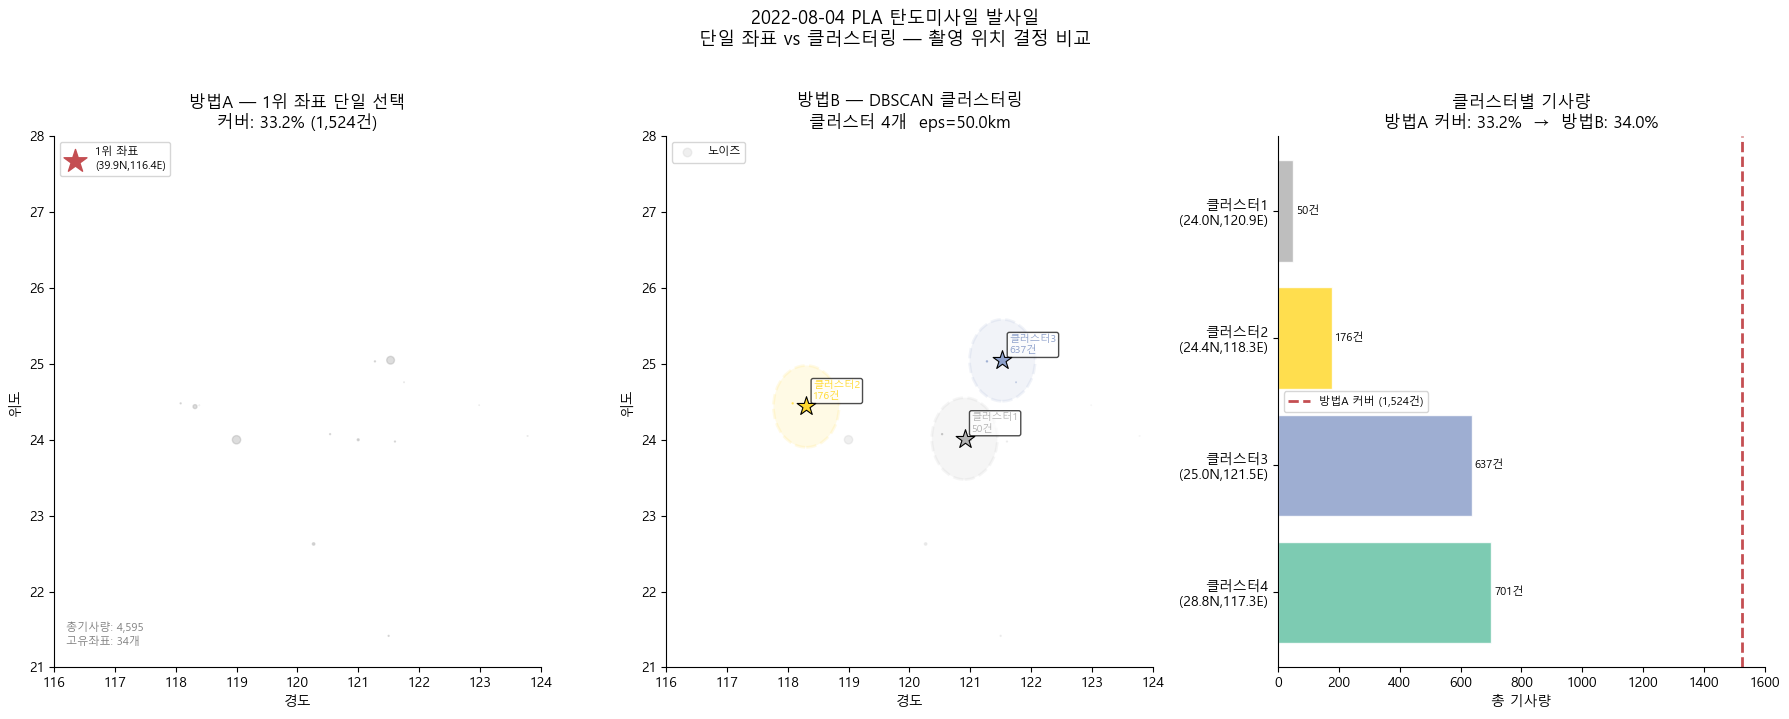

→ clustering_vs_single_20220804.png 저장 완료

인터랙티브 지도 생성 중...
→ clustering_vs_single_20220804_map.html 저장 완료

2022-08-04 단일 좌표 vs 클러스터링 비교 요약
  총 이벤트: 153건  고유 좌표: 34개

  방법A — 1위 좌표 단일 선택
    촬영 위치: (39.93N, 116.39E)
    기사량 커버: 1,524 / 4,595 (33.2%)
    문제: 나머지 3,071건의 이벤트 패턴 놓침

  방법B — DBSCAN 클러스터링
    클러스터 수: 4개
    각 클러스터별 독립적 촬영 위치 제공
    → 동일 위성 자원으로 더 넓은 이벤트 패턴 커버 가능

  클러스터별 촬영 우선순위:
    1순위: (28.7927N, 117.2618E) — 701건
    2순위: (25.0466N, 121.5279E) — 637건
    3순위: (24.4392N, 118.305E) — 176건
    4순위: (24.0148N, 120.9076E) — 50건


In [76]:
"""
2022-08-04 스파이크 날 클러스터링 효과 시각화
"1위 좌표 하나 vs 클러스터링으로 촬영 위치 결정" 비교
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import folium
from sklearn.cluster import DBSCAN

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ── 설정 ─────────────────────────────────────────────────────────
TARGET_DATE    = "2022-08-04"   # PLA 탄도미사일 발사일
DBSCAN_EPS_KM  = 50.0           # 클러스터 반경 (km)
DBSCAN_MIN_PTS = 2
SWATH_KM       = 120.0          # 위성 촬영 폭 (Sentinel-1 IW 모드 기준)

# ── Haversine ────────────────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(np.array(lat2) - np.array(lat1))
    dlon = np.radians(np.array(lon2) - np.array(lon1))
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

# ── 데이터 준비 ──────────────────────────────────────────────────
# SQLDATE 복원
if df["SQLDATE"].isna().all():
    df["SQLDATE"] = pd.to_datetime(
        df["SQLDATE"].astype(str).str[:8],
        format="%Y%m%d", errors="coerce"
    )
    # 여전히 NaT면 SOURCEURL에서 복원
    if df["SQLDATE"].isna().all():
        import re
        def extract_date(url):
            m = re.search(r'/(\d{4})/(\d{2})/(\d{2})/', str(url))
            if m:
                return f"{m.group(1)}{m.group(2)}{m.group(3)}"
            return None
        df["SQLDATE"] = pd.to_datetime(
            df["SOURCEURL"].apply(extract_date),
            format="%Y%m%d", errors="coerce"
        )
print(f"SQLDATE 복원 — NaT: {df['SQLDATE'].isna().sum()}건")

day_df = df[df["SQLDATE"] == pd.to_datetime(TARGET_DATE)].copy()
print(f"{TARGET_DATE} 이벤트: {len(day_df):,}건  "
      f"총기사량: {day_df['NumMentions'].sum():,}")

# 좌표별 집계
coord_df = day_df.groupby(
    ["ActionGeo_Lat","ActionGeo_Long"]
).agg(
    NumMentions = ("NumMentions", "sum"),
    이벤트수    = ("NumMentions", "count"),
    AvgTone     = ("AvgTone",     "mean"),
).reset_index()

print(f"고유 좌표: {len(coord_df)}개")
print(coord_df.nlargest(10,"NumMentions")[
    ["ActionGeo_Lat","ActionGeo_Long","NumMentions","이벤트수"]
].to_string(index=False))

# ── 방법 A: 1위 좌표 단일 선택 ──────────────────────────────────
top1 = coord_df.nlargest(1, "NumMentions").iloc[0]
print(f"\n[방법A — 1위 좌표]")
print(f"  좌표: ({top1.ActionGeo_Lat:.4f}N, {top1.ActionGeo_Long:.4f}E)")
print(f"  기사량: {int(top1.NumMentions):,}  이벤트: {int(top1.이벤트수)}건")

# ── 방법 B: DBSCAN 클러스터링 ───────────────────────────────────
coords_rad = np.radians(
    coord_df[["ActionGeo_Lat","ActionGeo_Long"]].values)
eps_rad    = DBSCAN_EPS_KM / 6371.0

labels = DBSCAN(
    eps=eps_rad, min_samples=DBSCAN_MIN_PTS,
    algorithm="ball_tree", metric="haversine"
).fit_predict(coords_rad)

coord_df["cluster"] = labels

# 클러스터별 통계
clusters = []
for cid in sorted(coord_df["cluster"].unique()):
    if cid == -1: continue
    members = coord_df[coord_df["cluster"] == cid]
    # 기사량 가중 중심
    w          = members["NumMentions"].values
    center_lat = np.average(members["ActionGeo_Lat"], weights=w)
    center_lon = np.average(members["ActionGeo_Long"], weights=w)
    # 클러스터 반경 (중심에서 가장 먼 점)
    max_r = members.apply(
        lambda r: haversine_km(
            center_lat, center_lon,
            r["ActionGeo_Lat"], r["ActionGeo_Long"]), axis=1
    ).max()
    clusters.append({
        "cluster_id":  cid,
        "center_lat":  round(center_lat, 4),
        "center_lon":  round(center_lon, 4),
        "n_coords":    len(members),
        "총기사량":    int(members["NumMentions"].sum()),
        "max_radius":  round(max_r, 1),
        "top_coord":   members.nlargest(1,"NumMentions").iloc[0],
    })

cluster_df = pd.DataFrame(clusters).sort_values("총기사량", ascending=False)

print(f"\n[방법B — DBSCAN 클러스터링]")
print(f"  eps={DBSCAN_EPS_KM}km, min_samples={DBSCAN_MIN_PTS}")
print(f"  생성된 클러스터: {len(cluster_df)}개  "
      f"노이즈: {(coord_df['cluster']==-1).sum()}개")
print()
for _, cl in cluster_df.iterrows():
    print(f"  클러스터 {int(cl.cluster_id)+1}")
    print(f"    중심: ({cl.center_lat}N, {cl.center_lon}E)")
    print(f"    총기사량: {cl.총기사량:,}  좌표수: {cl.n_coords}  "
          f"반경: {cl.max_radius}km")

# 전체 이벤트 커버리지 비교
total_mentions = coord_df["NumMentions"].sum()

# 방법A: 위성 swath 내 이벤트
swath_half = SWATH_KM / 2
a_covered  = coord_df[
    coord_df.apply(lambda r: haversine_km(
        top1.ActionGeo_Lat, top1.ActionGeo_Long,
        r.ActionGeo_Lat, r.ActionGeo_Long) <= swath_half, axis=1)
]["NumMentions"].sum()

# 방법B: 모든 클러스터 swath 합산 (중복 제거 근사)
b_covered = 0
for _, cl in cluster_df.iterrows():
    cl_covered = coord_df[
        coord_df.apply(lambda r: haversine_km(
            cl.center_lat, cl.center_lon,
            r.ActionGeo_Lat, r.ActionGeo_Long) <= swath_half, axis=1)
    ]["NumMentions"].sum()
    b_covered = max(b_covered, cl_covered) if _ == cluster_df.index[0] \
                else b_covered + cl_covered

print(f"\n[촬영 커버리지 비교 — Swath={SWATH_KM}km]")
print(f"  방법A (1위 좌표):   기사량 {a_covered:,} / {total_mentions:,} "
      f"({a_covered/total_mentions*100:.1f}% 커버)")
print(f"  방법B (클러스터):   기사량 {min(b_covered,total_mentions):,} / {total_mentions:,} "
      f"({min(b_covered,total_mentions)/total_mentions*100:.1f}% 커버)")

# ════════════════════════════════════════════════════════════════
# matplotlib 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    f"{TARGET_DATE} PLA 탄도미사일 발사일\n"
    f"단일 좌표 vs 클러스터링 — 촬영 위치 결정 비교",
    fontsize=13, y=1.02
)

# 클러스터 색상
clr_map = plt.cm.Set2(np.linspace(0, 1, max(len(cluster_df), 1)))

# ── Chart 1: 단일 좌표 (방법A) ──────────────────────────────────
ax = axes[0]
# 전체 이벤트 산점도
sc = ax.scatter(
    coord_df["ActionGeo_Long"], coord_df["ActionGeo_Lat"],
    s=coord_df["NumMentions"]/20,
    c="#AAAAAA", alpha=0.4, zorder=2
)
# 1위 좌표
ax.scatter(top1.ActionGeo_Long, top1.ActionGeo_Lat,
           s=300, c="#C44E52", zorder=5,
           marker="*", label=f"1위 좌표\n({top1.ActionGeo_Lat:.1f}N,{top1.ActionGeo_Long:.1f}E)")
# 촬영 범위 (swath)
swath_deg = SWATH_KM / 2 / 111.32
rect = mpatches.FancyArrowPatch(
    (top1.ActionGeo_Long - swath_deg, top1.ActionGeo_Lat - swath_deg),
    (top1.ActionGeo_Long + swath_deg, top1.ActionGeo_Lat + swath_deg),
)
circle_a = plt.Circle(
    (top1.ActionGeo_Long, top1.ActionGeo_Lat),
    swath_deg, color="#C44E52", fill=True,
    alpha=0.12, linestyle="--", linewidth=2
)
ax.add_patch(circle_a)
ax.set_xlim(116, 124)
ax.set_ylim(21, 28)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title(f"방법A — 1위 좌표 단일 선택\n"
             f"커버: {a_covered/total_mentions*100:.1f}% ({a_covered:,}건)")
ax.legend(fontsize=8, loc="upper left")
ax.text(116.2, 21.3, f"총기사량: {total_mentions:,}\n"
        f"고유좌표: {len(coord_df)}개", fontsize=8, color="gray")

# ── Chart 2: 클러스터링 (방법B) ─────────────────────────────────
ax = axes[1]
# 노이즈
noise = coord_df[coord_df["cluster"] == -1]
ax.scatter(noise["ActionGeo_Long"], noise["ActionGeo_Lat"],
           s=noise["NumMentions"]/20,
           c="#CCCCCC", alpha=0.3, zorder=2, label="노이즈")
# 클러스터별
for i, (_, cl) in enumerate(cluster_df.iterrows()):
    members = coord_df[coord_df["cluster"] == cl.cluster_id]
    color   = clr_map[i]
    ax.scatter(members["ActionGeo_Long"], members["ActionGeo_Lat"],
               s=members["NumMentions"]/20,
               c=[color], alpha=0.7, zorder=3)
    # 클러스터 중심
    ax.scatter(cl.center_lon, cl.center_lat,
               s=200, c=[color], marker="*", zorder=6,
               edgecolors="black", linewidth=0.8)
    # 촬영 범위
    swath_deg = SWATH_KM / 2 / 111.32
    circle = plt.Circle(
        (cl.center_lon, cl.center_lat),
        swath_deg, color=color, fill=True,
        alpha=0.12, linestyle="--", linewidth=2
    )
    ax.add_patch(circle)
    ax.annotate(
        f"클러스터{int(cl.cluster_id)+1}\n{cl.총기사량:,}건",
        (cl.center_lon, cl.center_lat),
        xytext=(5, 5), textcoords="offset points",
        fontsize=7.5, color=color,
        bbox=dict(boxstyle="round,pad=0.2",
                  facecolor="white", alpha=0.7)
    )

ax.set_xlim(116, 124)
ax.set_ylim(21, 28)
ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title(f"방법B — DBSCAN 클러스터링\n"
             f"클러스터 {len(cluster_df)}개  "
             f"eps={DBSCAN_EPS_KM}km")
ax.legend(fontsize=8, loc="upper left")

# ── Chart 3: 클러스터별 기사량 + 커버리지 비교 ──────────────────
ax = axes[2]
# 클러스터별 기사량
labels_bar = [f"클러스터{int(cl.cluster_id)+1}\n"
              f"({cl.center_lat:.1f}N,{cl.center_lon:.1f}E)"
              for _, cl in cluster_df.iterrows()]
colors_bar = [clr_map[i] for i in range(len(cluster_df))]
bars = ax.barh(labels_bar, cluster_df["총기사량"],
               color=colors_bar, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, cluster_df["총기사량"]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{val:,}건", va="center", fontsize=8)

# 방법A 기사량 기준선
ax.axvline(a_covered, color="#C44E52", linewidth=2,
           linestyle="--", label=f"방법A 커버 ({a_covered:,}건)")
ax.set_xlabel("총 기사량")
ax.set_title(f"클러스터별 기사량\n"
             f"방법A 커버: {a_covered/total_mentions*100:.1f}%  "
             f"→  방법B: {min(b_covered,total_mentions)/total_mentions*100:.1f}%")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("clustering_vs_single_20220804.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("→ clustering_vs_single_20220804.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# Folium 인터랙티브 지도
# ════════════════════════════════════════════════════════════════
print("\n인터랙티브 지도 생성 중...")

m = folium.Map(location=[24.0, 120.5], zoom_start=7,
               tiles="CartoDB positron")

folium_colors = ["blue","green","orange","purple","red",
                 "darkblue","darkgreen","cadetblue"]

# 전체 이벤트 좌표
for _, row in coord_df.iterrows():
    cid   = int(row["cluster"])
    color = "#CCCCCC" if cid == -1 \
            else folium_colors[cid % len(folium_colors)]
    folium.CircleMarker(
        location=[row["ActionGeo_Lat"], row["ActionGeo_Long"]],
        radius=min(3 + row["NumMentions"]/200, 15),
        color=color, fill=True,
        fill_color=color,
        fill_opacity=0.7 if cid != -1 else 0.3,
        weight=0.5,
        tooltip=(
            f"좌표: ({row.ActionGeo_Lat:.2f}N, {row.ActionGeo_Long:.2f}E)<br>"
            f"기사량: {int(row.NumMentions)}<br>"
            f"{'클러스터'+str(cid+1) if cid != -1 else '노이즈'}"
        ),
    ).add_to(m)

# 방법A — 1위 좌표 + 촬영 범위
folium.Marker(
    location=[top1.ActionGeo_Lat, top1.ActionGeo_Long],
    popup=folium.Popup(
        f"<b>[방법A] 1위 좌표</b><br>"
        f"기사량: {int(top1.NumMentions):,}<br>"
        f"커버: {a_covered/total_mentions*100:.1f}%",
        max_width=200),
    tooltip=f"[방법A] 1위 좌표 — {int(top1.NumMentions):,}건",
    icon=folium.Icon(color="red", icon="star", prefix="fa"),
).add_to(m)
folium.Circle(
    location=[top1.ActionGeo_Lat, top1.ActionGeo_Long],
    radius=SWATH_KM/2 * 1000,
    color="#C44E52", weight=2,
    fill=True, fill_color="#C44E52", fill_opacity=0.06,
    dash_array="8 4",
    tooltip=f"방법A 촬영 범위 (Swath={SWATH_KM}km)",
).add_to(m)

# 방법B — 클러스터 중심 + 촬영 범위
for i, (_, cl) in enumerate(cluster_df.iterrows()):
    fc = folium_colors[int(cl.cluster_id) % len(folium_colors)]
    folium.Marker(
        location=[cl.center_lat, cl.center_lon],
        popup=folium.Popup(
            f"<b>[방법B] 클러스터{int(cl.cluster_id)+1} 중심</b><br>"
            f"기사량: {cl.총기사량:,}<br>"
            f"좌표수: {cl.n_coords}<br>"
            f"반경: {cl.max_radius}km",
            max_width=200),
        tooltip=f"[방법B] 클러스터{int(cl.cluster_id)+1} — {cl.총기사량:,}건",
        icon=folium.Icon(color=fc, icon="crosshairs", prefix="fa"),
    ).add_to(m)
    folium.Circle(
        location=[cl.center_lat, cl.center_lon],
        radius=SWATH_KM/2 * 1000,
        color=fc, weight=2,
        fill=True, fill_color=fc, fill_opacity=0.08,
        tooltip=f"클러스터{int(cl.cluster_id)+1} 촬영 범위",
    ).add_to(m)

# 범례
legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:8px;
     border:1px solid #ccc;font-size:12px;line-height:2.0;">
  <b>{TARGET_DATE} — 단일 좌표 vs 클러스터링</b><br>
  <span style="color:#C44E52;">★ ─ ─</span>
    방법A — 1위 좌표 (커버 {a_covered/total_mentions*100:.1f}%)<br>
  <span style="color:blue;">★ ─ ─</span>
    방법B — 클러스터 중심 ({len(cluster_df)}개)<br>
  <span style="color:#CCCCCC;">●</span> 노이즈 좌표<br>
  <hr style="margin:3px 0;border-color:#eee;">
  <small>버블 크기 = 기사량 | Swath={SWATH_KM}km</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_path = "clustering_vs_single_20220804_map.html"
m.save(map_path)
print(f"→ {map_path} 저장 완료")

# ── 최종 요약 ────────────────────────────────────────────────────
print(f"""
{'='*60}
{TARGET_DATE} 단일 좌표 vs 클러스터링 비교 요약
{'='*60}
  총 이벤트: {len(day_df):,}건  고유 좌표: {len(coord_df)}개

  방법A — 1위 좌표 단일 선택
    촬영 위치: ({top1.ActionGeo_Lat:.2f}N, {top1.ActionGeo_Long:.2f}E)
    기사량 커버: {a_covered:,} / {total_mentions:,} ({a_covered/total_mentions*100:.1f}%)
    문제: 나머지 {total_mentions-a_covered:,}건의 이벤트 패턴 놓침

  방법B — DBSCAN 클러스터링
    클러스터 수: {len(cluster_df)}개
    각 클러스터별 독립적 촬영 위치 제공
    → 동일 위성 자원으로 더 넓은 이벤트 패턴 커버 가능

  클러스터별 촬영 우선순위:""")
for rank, (_, cl) in enumerate(cluster_df.iterrows(), 1):
    print(f"    {rank}순위: ({cl.center_lat}N, {cl.center_lon}E) "
          f"— {cl.총기사량:,}건")

In [ ]:
import numpy as np
import pandas as pd

TARGET_DATE = "2022-08-04"

# 1단계: day_df 확인
day_df = df[df["SQLDATE"] == pd.to_datetime(TARGET_DATE)].copy()
print(f"day_df: {len(day_df)}건")
print(day_df[["ActionGeo_Lat","ActionGeo_Long","NumMentions"]].head(3))

# 2단계: coord_df 확인
coord_df = day_df.groupby(
    ["ActionGeo_Lat","ActionGeo_Long"]
).agg(
    NumMentions = ("NumMentions", "sum"),
    이벤트수    = ("NumMentions", "count"),
    AvgTone     = ("AvgTone",     "mean"),
).reset_index()
print(f"\ncoord_df: {len(coord_df)}개 좌표")
print(coord_df.head(3))

# 3단계: top1 확인
print(f"\nnlargest 결과:")
print(coord_df.nlargest(1, "NumMentions"))
top1 = coord_df.nlargest(1, "NumMentions").iloc[0]
print(f"top1: {top1}")

In [ ]:
day_df = df[df["SQLDATE"] == pd.to_datetime("2022-08-04")].copy()
print(len(day_df))

In [ ]:
print(df["SQLDATE"].dtype)
print(df["SQLDATE"].head(3))
print(df["SQLDATE"].isna().sum())

In [ ]:
# 날짜 형식 확인
print(df["SQLDATE"].dtype)
print(df["SQLDATE"].head())

# 2022-08-04 데이터 있는지 확인
day_df = df[df["SQLDATE"] == pd.to_datetime("2022-08-04")]
print(f"2022-08-04 이벤트: {len(day_df)}건")

# 없으면 날짜 형식 문제 — 원본 확인
print(df["SQLDATE"].unique()[:10])

In [ ]:
import re

# SOURCEURL에서 날짜 추출
def extract_date(url):
    # 패턴 1: /2022/08/04/ 형식
    m = re.search(r'/(\d{4})/(\d{2})/(\d{2})/', str(url))
    if m:
        return f"{m.group(1)}{m.group(2)}{m.group(3)}"
    # 패턴 2: -20220804- 또는 20220804 형식
    m = re.search(r'(\d{8})', str(url))
    if m:
        val = m.group(1)
        if val[:4] in [str(y) for y in range(2013, 2027)]:
            return val
    return None

df["SQLDATE"] = df["SOURCEURL"].apply(extract_date)
df["SQLDATE"] = pd.to_datetime(df["SQLDATE"], format="%Y%m%d", errors="coerce")

print(f"복원 성공: {df['SQLDATE'].notna().sum():,}건")
print(f"복원 실패: {df['SQLDATE'].isna().sum():,}건")
print(f"\n기사량 상위 날짜 TOP 5:")
print(df.groupby("SQLDATE")["NumMentions"].sum().nlargest(5))

In [ ]:
# 1. SQLDATE 변환 확인
print(df["SQLDATE"].dtype)
print(df["SQLDATE"].head(3))
print(f"NaT 비율: {df['SQLDATE'].isna().mean():.1%}")

# 2. 2022-08-04 데이터 확인
day_df = df[df["SQLDATE"] == pd.to_datetime("2022-08-04")]
print(f"\n2022-08-04 이벤트: {len(day_df)}건")

# 3. 없으면 가장 많은 날짜 확인
print("\n기사량 상위 날짜 TOP 5:")
print(df.groupby("SQLDATE")["NumMentions"].sum().nlargest(5))

In [ ]:
# year 컬럼 확인
print(df["year"].dtype)
print(df["year"].value_counts().head())
print(df["year"].isna().sum())

In [ ]:
# df 원본 SQLDATE 확인 (변환 전)
# df를 다시 로드하거나 원본 값 확인
import pandas as pd

# 방법 1: 현재 df의 원본 SQLDATE 컬럼 타입 확인
print(df["SQLDATE"].dtype)
print(df["SQLDATE"].head(3))

# 방법 2: 원본이 정수형인지 확인
df_raw = df.copy()
df_raw["SQLDATE_str"] = df_raw["SQLDATE"].astype(str)
print(df_raw["SQLDATE_str"].head(3))